# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



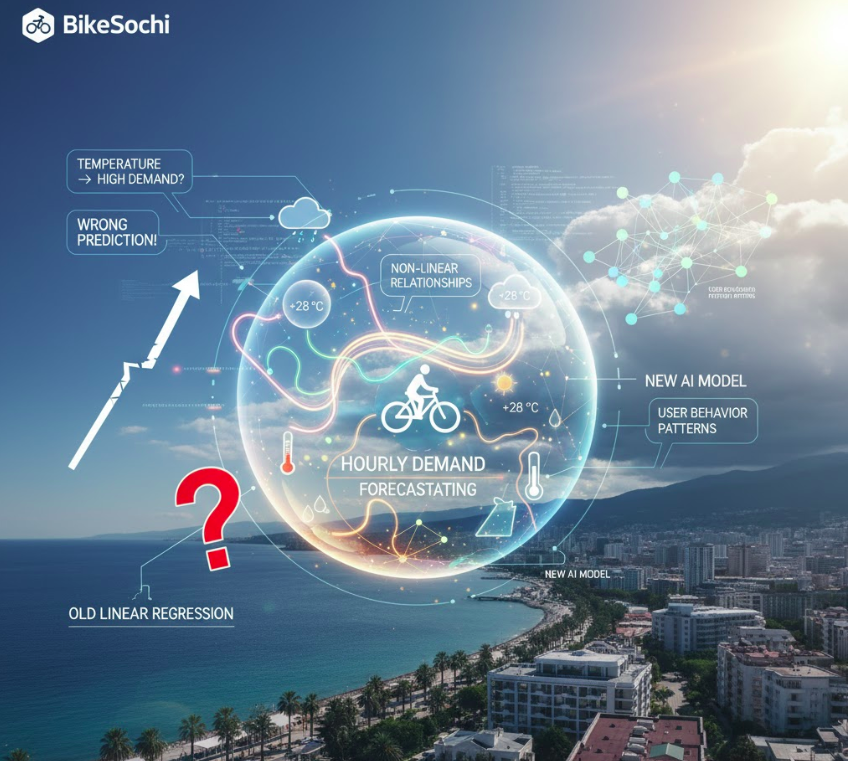

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— `models/baseline_linear_regression_pipeline.joblib` — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть `models/baseline_linear_regression_pipeline.joblib`, `data/raw/ds_s14_train_data.csv` и `data/raw/ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите `.joblib` файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**

<a id="author-solution"></a>
# Авторское решение: прогнозирование спроса на велопрокат BikeSouth

Смысл задачи простой: BikeSouth нужно заранее понимать, сколько велосипедов понадобится в конкретный час. Если прогноз завышен, компания зря держит лишний парк и смены. Если занижен, в пиковые часы людям не хватит велосипедов.

**Цель:** выбрать модель, которая лучше текущей линейной регрессии прогнозирует `Rented Bike Count` и не выдает невозможный отрицательный спрос.

**Основная метрика:** `RMSE`, потому что крупные промахи в пиковые часы для проката особенно дороги. Дополнительно считаю `MAE` и `R2`: `MAE` показывает типичную ошибку в велосипедах в час, а `R2` помогает понять, насколько модель объясняет изменчивость спроса относительно простого среднего.

**Ключевое ограничение:** `ds_s14_test_data.csv` не используется для подбора гиперпараметров и выбора модели. Новые модели выбираются только по 5-fold CV на `ds_s14_train_data.csv`; test применяется один раз в конце.


<a id="navigation"></a>
## Навигация по исследованию

1. [Методологическая рамка](#methodology)
2. [Этап 1. Среда, константы и пути](#stage-1)
3. [Этап 2. Загрузка данных и контракт схемы](#stage-2)
4. [Этап 3. Baseline компании](#stage-3)
5. [Этап 4. Первичный аудит и EDA](#stage-4)
6. [Этап 5. Pipeline и feature engineering](#stage-5)
7. [Этап 6. Optuna и 5-fold CV](#stage-6)
8. [Этап 7. Финальная проверка на test](#stage-7)
9. [Этап 7.1. Сегментный аудит против baseline](#stage-7-1)
10. [Этап 8. Интерпретация и артефакты](#stage-8)
11. [Финальные выводы](#final-conclusions)


<a id="methodology"></a>
## Методологическая рамка

Здесь важно не "выжать красивую метрику", а честно проверить модель. Если test попадет в подбор параметров, результат будет выглядеть лучше, чем он есть на самом деле. Поэтому правила эксперимента фиксируются до моделирования.

- Все обучаемые преобразования (`imputer`, `scaler`, `encoder`, модель) живут внутри `Pipeline`.
- Финальная test-выборка не участвует в Optuna, выборе модели или выборе признаков.
- Для новых моделей используется единая `KFold(n_splits=5, shuffle=True, random_state=42)`.
- В Optuna минимизируется RMSE. Так как `sklearn` для regression scoring возвращает отрицательные значения, в objective используется `-scores["test_rmse"].mean()`.
- Baseline компании оценивается отдельно как предоставленная модель. Его test-метрики нужны для итогового сравнения, но не для настройки новых моделей.
- Графики используются не декоративно: каждый блок EDA должен дать решение для предобработки, признаков или интерпретации.
- Технические названия признаков остаются видимыми, а русский смысл дается в круглых скобках. Так ревьювер видит исходную схему данных, а бизнес-заказчик не теряет смысл.
- После общей test-метрики отдельно проверяется, в каких сегментах новая модель выигрывает у baseline. Средний `RMSE` важен, но для проката еще важнее понимать часы и условия, где ошибка реально стала меньше.
- Финальная рекомендация должна отвечать на операционные вопросы: насколько ошибка меньше baseline, исчезли ли невозможные отрицательные прогнозы, какие факторы мониторить и почему модель нельзя запускать без проверки на свежем периоде.


<a id="stage-1"></a>
## Этап 1. Среда, константы и пути

Сначала фиксирую импорты, настройки отображения, seed и рабочие пути. Это защищает ноутбук от скрытого состояния: его можно перезапустить сверху вниз и получить те же фолды, те же trials Optuna и те же метрики.


In [1]:
from __future__ import annotations

import hashlib
import importlib
import json
import platform
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
CV_SPLITS = 5
N_TRIALS_KNN = 35
N_TRIALS_TREE = 45
TARGET_ORIGINAL = "Rented Bike Count"
TARGET = "rented_bike_count"

def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        has_project_files = all(
            [
                (candidate / "data" / "raw" / "ds_s14_train_data.csv").exists(),
                (candidate / "data" / "raw" / "ds_s14_test_data.csv").exists(),
                (candidate / "models" / "baseline_linear_regression_pipeline.joblib").exists(),
            ]
        )
        if has_project_files:
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
COMPONENT_MODULE_NAME = "bike_demand_pipeline_components"
COMPONENT_MODULE_PATH = PROJECT_ROOT / f"{COMPONENT_MODULE_NAME}.py"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

versions = pd.DataFrame(
    [
        {"package": "python", "version": platform.python_version()},
        {"package": "pandas", "version": pd.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "optuna", "version": optuna.__version__},
        {"package": "joblib", "version": joblib.__version__},
    ]
)
display(versions)


D:\DS\13\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,package,version
0,python,3.11.9
1,pandas,3.0.2
2,numpy,2.4.3
3,scikit-learn,1.6.1
4,optuna,4.9.0
5,joblib,1.5.3


**Подвывод по этапу 1:** окружение готово к повторному запуску. Самая важная деталь - `scikit-learn 1.6.1`: на этой версии без ошибок открывается baseline из `joblib`.


<a id="stage-2"></a>
## Этап 2. Загрузка данных и контракт схемы

CSV-файлы приходят с человекочитаемыми названиями колонок, а предоставленный baseline pipeline ожидает `snake_case`. Поэтому сначала создаю единую функцию нормализации схемы. Это снижает риск, что baseline и новые модели будут обучаться на разных представлениях одних и тех же данных.


In [2]:
COLUMN_RENAME = {
    "Temperature": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "wind_speed_ms",
    "Visibility (10m)": "visibility_10m",
    "Dew point temperature": "dew_point_temperature",
    "Solar Radiation (MJ/m2)": "solar_radiation_mjm2",
    "Rainfall(mm)": "rainfallmm",
    "Snowfall (cm)": "snowfall_cm",
    "Seasons": "seasons",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day",
    "Time_Period_Evening": "time_period_evening",
    "Time_Period_Late Evening": "time_period_late_evening",
    "Time_Period_Morning": "time_period_morning",
    "Time_Period_Night": "time_period_night",
    TARGET_ORIGINAL: TARGET,
}

BASE_NUMERIC_FEATURES = [
    "temperature",
    "humidity",
    "wind_speed_ms",
    "visibility_10m",
    "dew_point_temperature",
    "solar_radiation_mjm2",
    "rainfallmm",
    "snowfall_cm",
]
CATEGORICAL_FEATURES = ["seasons", "holiday", "functioning_day"]
TIME_FEATURES = [
    "time_period_evening",
    "time_period_late_evening",
    "time_period_morning",
    "time_period_night",
]
BASE_FEATURES = BASE_NUMERIC_FEATURES + CATEGORICAL_FEATURES + TIME_FEATURES

FEATURE_DESCRIPTIONS_RU = {
    "rented_bike_count": "спрос на велосипеды",
    "temperature": "температура воздуха",
    "humidity": "влажность воздуха",
    "wind_speed_ms": "скорость ветра",
    "visibility_10m": "видимость",
    "dew_point_temperature": "температура точки росы",
    "solar_radiation_mjm2": "солнечная радиация",
    "rainfallmm": "количество осадков, дождь",
    "snowfall_cm": "количество снега",
    "seasons": "сезон",
    "holiday": "праздничный день",
    "functioning_day": "работает ли прокат",
    "seasons_Spring": "весенний сезон",
    "seasons_Summer": "летний сезон",
    "seasons_Autumn": "осенний сезон",
    "seasons_Winter": "зимний сезон",
    "holiday_Holiday": "праздничный день",
    "holiday_No Holiday": "не праздничный день",
    "functioning_day_Yes": "прокат работает",
    "functioning_day_No": "прокат не работает",
    "time_period_evening": "вечерний период",
    "time_period_late_evening": "поздний вечер",
    "time_period_morning": "утренний период",
    "time_period_night": "ночной период",
    "time_period_daytime": "дневной период",
    "rainfall_flag": "наличие дождя",
    "snowfall_flag": "наличие снега",
    "dew_point_gap": "разница температуры и точки росы",
    "comfort_temperature": "комфортный диапазон температуры",
    "low_visibility_flag": "низкая видимость",
    "temperature_x_humidity": "взаимодействие температуры и влажности",
    "temperature_x_solar": "взаимодействие температуры и солнечной радиации",
}

FEATURE_UNITS = {
    "rented_bike_count": "велосипедов в час",
    "temperature": "°C",
    "humidity": "%",
    "wind_speed_ms": "м/с",
    "visibility_10m": "единицы по 10 м",
    "dew_point_temperature": "°C",
    "solar_radiation_mjm2": "МДж/м²",
    "rainfallmm": "мм",
    "snowfall_cm": "см",
}

PARAMETER_DESCRIPTIONS_RU = {
    "n_neighbors": "число соседей",
    "weights": "веса соседей",
    "p": "метрика Минковского",
    "leaf_size": "размер листа поиска",
    "max_depth": "максимальная глубина",
    "min_samples_split": "минимум объектов для split",
    "min_samples_leaf": "минимум объектов в листе",
    "max_features": "число признаков для split",
    "ccp_alpha": "сила pruning",
    "random_state": "seed",
    "strategy": "стратегия dummy",
}


def feature_label_for_reader(feature: str) -> tuple[str, str, str]:
    technical = feature.replace("num__", "").replace("cat__", "")
    description = FEATURE_DESCRIPTIONS_RU.get(technical, technical.replace("_", " "))
    plot_label = f"{technical}\n({description})" if description != technical else technical
    return technical, description, plot_label


def inline_feature_label(feature: str, *, with_unit: bool = False) -> str:
    technical, description, _ = feature_label_for_reader(feature)
    label = f"{technical} ({description})" if description != technical else technical
    unit = FEATURE_UNITS.get(technical)
    return f"{label}, {unit}" if with_unit and unit else label


def short_params_for_plot(model_name: str, params: Dict[str, Any]) -> str:
    if not params:
        return "strategy=mean (среднее)"
    if model_name == "decision_tree_optuna":
        keys = ["max_depth", "min_samples_leaf", "min_samples_split"]
    elif model_name == "knn_optuna":
        keys = ["n_neighbors", "weights", "p"]
    else:
        keys = list(params)[:3]
    parts = []
    for key in keys:
        if key in params:
            parts.append(f"{key}={params[key]} ({PARAMETER_DESCRIPTIONS_RU.get(key, key)})")
    return "\n".join(parts)


def add_bar_labels(ax: plt.Axes, fmt: str) -> None:
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


def read_csv_with_fallback(filename: str) -> pd.DataFrame:
    candidates = [DATA_DIR / filename, Path("/datasets") / filename]
    for candidate in candidates:
        if candidate.exists():
            return pd.read_csv(candidate)
    raise FileNotFoundError(f"Could not find {filename} in: {candidates}")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df.rename(columns=COLUMN_RENAME).copy()
    expected = set(COLUMN_RENAME.values())
    missing = sorted(expected - set(normalized.columns))
    if missing:
        raise ValueError(f"Missing expected columns after normalization: {missing}")
    return normalized[list(COLUMN_RENAME.values())]


train_raw = read_csv_with_fallback("ds_s14_train_data.csv")
test_raw = read_csv_with_fallback("ds_s14_test_data.csv")
train = normalize_columns(train_raw)
test = normalize_columns(test_raw)

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]
X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

data_overview = pd.DataFrame(
    [
        {"dataset": "train", "rows": train.shape[0], "columns": train.shape[1]},
        {"dataset": "test", "rows": test.shape[0], "columns": test.shape[1]},
    ]
)
display(data_overview)
display(train.head())

raw_feature_set = set(BASE_FEATURES)
feature_dictionary = pd.DataFrame(
    [
        {
            "technical_name": technical_name,
            "description_ru": description,
            "role": "исходный признак" if technical_name in raw_feature_set else "инженерный или encoded-признак",
        }
        for technical_name, description in FEATURE_DESCRIPTIONS_RU.items()
    ]
)
display(feature_dictionary)

assert train.shape == (7008, 16), "Unexpected train shape"
assert test.shape == (1752, 16), "Unexpected test shape"
assert list(train.columns) == list(test.columns), "Train/test schemas differ"
assert TARGET in train.columns and TARGET in test.columns


,dataset,rows,columns
0,train,7008,16
1,test,1752,16


,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
0,20.3000,35.0000,2.4000,"2,000.0000",4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4000,55.0000,3.2000,"2,000.0000",15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9000,39.0000,1.6000,"2,000.0000",-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2000,37.0000,2.2000,"2,000.0000",-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4000,34.0000,2.1000,"2,000.0000",6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686


,technical_name,description_ru,role
0,rented_bike_count,спрос на велосипеды,инженерный или encoded-признак
1,temperature,температура воздуха,исходный признак
2,humidity,влажность воздуха,исходный признак
3,wind_speed_ms,скорость ветра,исходный признак
4,visibility_10m,видимость,исходный признак
5,dew_point_temperature,температура точки росы,исходный признак
6,solar_radiation_mjm2,солнечная радиация,исходный признак
7,rainfallmm,"количество осадков, дождь",исходный признак
8,snowfall_cm,количество снега,исходный признак
9,seasons,сезон,исходный признак


**Подвывод по этапу 2:** train содержит `7008` строк, test - `1752`; набор колонок совпадает. Сразу задан словарь `technical_name -> description_ru`, поэтому дальше в таблицах и графиках остаются настоящие имена колонок, но рядом есть нормальное русское пояснение.


<a id="stage-3"></a>
## Этап 3. Baseline компании

Компания предоставила готовый pipeline линейной регрессии. Его нужно не переобучать, а загрузить и оценить. Это дает точку сравнения: новая модель должна быть не просто обучена, а практически лучше текущего подхода BikeSouth.


In [3]:
baseline_path = MODELS_DIR / "baseline_linear_regression_pipeline.joblib"
baseline_pipeline = joblib.load(baseline_path)
print(baseline_pipeline)

baseline_blocks = []
for block_name, transformer, columns in baseline_pipeline.named_steps["preprocessor"].transformers_:
    baseline_blocks.append(
        {
            "block": block_name,
            "transformer": repr(transformer),
            "columns": ", ".join(columns),
        }
    )
display(pd.DataFrame(baseline_blocks))


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_temperature',
                                                   'solar_radiation_mjm2',
                                                   'rainfallmm',
                                                   'snowfall_cm']),
                                                 ('cat',
         

,block,transformer,columns
0,num,"Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),\n ('scaler', StandardScaler())])","temperature, humidity, wind_speed_ms, visibility_10m, dew_point_temperature, solar_radiation_mjm2, rainfallmm, snowfall_cm"
1,cat,"Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),\n ('onehot',\n OneHotEncoder(handle_unknown='ignore', sparse_output=False))])","seasons, holiday, functioning_day"
2,time,"FunctionTransformer(accept_sparse=True, check_inverse=False,\n feature_names_out='one-to-one')","time_period_evening, time_period_late_evening, time_period_morning, time_period_night"


In [4]:
def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "prediction_min": float(np.min(y_pred)),
        "prediction_max": float(np.max(y_pred)),
        "prediction_mean": float(np.mean(y_pred)),
        "negative_predictions": int(np.sum(y_pred < 0)),
    }


def evaluate_fitted_model(name: str, model: Pipeline, X: pd.DataFrame, y: pd.Series, split: str) -> Dict[str, Any]:
    predictions = model.predict(X)
    result = {"model": name, "split": split}
    result.update(regression_metrics(y, predictions))
    return result


baseline_results = pd.DataFrame(
    [
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_train, y_train, "train"),
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_test, y_test, "test"),
    ]
)
display(baseline_results)


,model,split,RMSE,MAE,R2,prediction_min,prediction_max,prediction_mean,negative_predictions
0,company_linear_baseline,train,412.4996,309.1525,0.5926,"-1,564.4103","1,944.8315",705.6060,608
1,company_linear_baseline,test,411.4545,312.5313,0.5863,-715.2865,"1,963.7774",715.3055,147


In [5]:
baseline_train_row = baseline_results.query("split == 'train'").iloc[0]
baseline_test_row_for_comment = baseline_results.query("split == 'test'").iloc[0]
baseline_negative_share = baseline_test_row_for_comment["negative_predictions"] / len(X_test)

display(
    Markdown(
        f"""
        **Расчетные итоги baseline**

        - Train RMSE: `{baseline_train_row["RMSE"]:.2f}`.
        - Test RMSE: `{baseline_test_row_for_comment["RMSE"]:.2f}`.
        - Test MAE: `{baseline_test_row_for_comment["MAE"]:.2f}`.
        - Test R2: `{baseline_test_row_for_comment["R2"]:.3f}`.
        - Отрицательные test-прогнозы: `{int(baseline_test_row_for_comment["negative_predictions"])}` из `{len(X_test)}` (`{baseline_negative_share:.1%}`).
        - Минимальный test-прогноз: `{baseline_test_row_for_comment["prediction_min"]:.2f}` велосипеда в час.
        """
    )
)



        **Расчетные итоги baseline**

        - Train RMSE: `412.50`.
        - Test RMSE: `411.45`.
        - Test MAE: `312.53`.
        - Test R2: `0.586`.
        - Отрицательные test-прогнозы: `147` из `1752` (`8.4%`).
        - Минимальный test-прогноз: `-715.29` велосипеда в час.
        

**Интерпретация baseline:** baseline не проваливается, но у него есть понятный дефект: линейная модель иногда уходит в отрицательный спрос. В реальной работе такие значения все равно пришлось бы обрезать руками. Значит новая модель должна не только снизить RMSE/MAE, но и вести себя здраво: спрос не может быть меньше нуля.


<a id="stage-4"></a>
## Этап 4. Первичный аудит и EDA

EDA здесь не для украшения. Каждый график должен ответить на практический вопрос: что делать с пропусками, какие признаки кодировать, где ждать нелинейность и какие факторы потом объяснять заказчику.


In [6]:
audit_rows = []
for dataset_name, df in [("train", train), ("test", test)]:
    audit_rows.append(
        {
            "dataset": dataset_name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "duplicates": int(df.duplicated().sum()),
            "target_min": float(df[TARGET].min()),
            "target_median": float(df[TARGET].median()),
            "target_mean": float(df[TARGET].mean()),
            "target_max": float(df[TARGET].max()),
            "zero_target_rows": int((df[TARGET] == 0).sum()),
            "zero_target_share": float((df[TARGET] == 0).mean()),
        }
    )

audit_overview = pd.DataFrame(audit_rows)
missing_report = pd.concat(
    [
        train.isna().sum().rename("train_missing"),
        (train.isna().mean() * 100).rename("train_missing_pct"),
        test.isna().sum().rename("test_missing"),
        (test.isna().mean() * 100).rename("test_missing_pct"),
        train.dtypes.astype(str).rename("dtype"),
    ],
    axis=1,
).reset_index(names="column")

category_report = []
for column in CATEGORICAL_FEATURES + TIME_FEATURES:
    category_report.append(
        {
            "column": column,
            "train_unique": train[column].nunique(dropna=False),
            "test_unique": test[column].nunique(dropna=False),
            "train_values": sorted(map(str, train[column].dropna().unique().tolist())),
            "test_values": sorted(map(str, test[column].dropna().unique().tolist())),
        }
    )

print("Общий аудит")
display(audit_overview)
print("Пропуски и типы")
display(missing_report)
print("Категориальные и дискретные значения")
display(pd.DataFrame(category_report))

assert audit_overview["duplicates"].sum() == 0, "Unexpected duplicate rows"
assert (train[TARGET] >= 0).all() and (test[TARGET] >= 0).all(), "Target contains negative values"


Общий аудит


,dataset,rows,columns,duplicates,target_min,target_median,target_mean,target_max,zero_target_rows,zero_target_share
0,train,7008,16,0,0.0000,504.5000,705.6060,"3,556.0000",242,0.0345
1,test,1752,16,0,0.0000,503.5000,700.5862,"3,380.0000",53,0.0303


Пропуски и типы


,column,train_missing,train_missing_pct,test_missing,test_missing_pct,dtype
0,temperature,0,0.0000,0,0.0000,float64
1,humidity,250,3.5674,72,4.1096,float64
2,wind_speed_ms,210,2.9966,52,2.9680,float64
3,visibility_10m,259,3.6958,72,4.1096,float64
4,dew_point_temperature,0,0.0000,0,0.0000,float64
5,solar_radiation_mjm2,210,2.9966,52,2.9680,float64
6,rainfallmm,262,3.7386,64,3.6530,float64
7,snowfall_cm,263,3.7529,61,3.4817,float64
8,seasons,0,0.0000,0,0.0000,str
9,holiday,0,0.0000,0,0.0000,str


Категориальные и дискретные значения


,column,train_unique,test_unique,train_values,test_values
0,seasons,4,4,"[Autumn, Spring, Summer, Winter]","[Autumn, Spring, Summer, Winter]"
1,holiday,2,2,"[Holiday, No Holiday]","[Holiday, No Holiday]"
2,functioning_day,2,2,"[No, Yes]","[No, Yes]"
3,time_period_evening,2,2,"[False, True]","[False, True]"
4,time_period_late_evening,2,2,"[False, True]","[False, True]"
5,time_period_morning,2,2,"[False, True]","[False, True]"
6,time_period_night,2,2,"[False, True]","[False, True]"


**Подвывод по аудиту:** дубликатов нет, target неотрицательный. Нулевой спрос есть, и это нормально: прокат может не работать или спрос может быть очень низким. Пропуски только в погодных числовых признаках, поэтому строки не удаляю; медианное заполнение будет обучаться внутри pipeline.


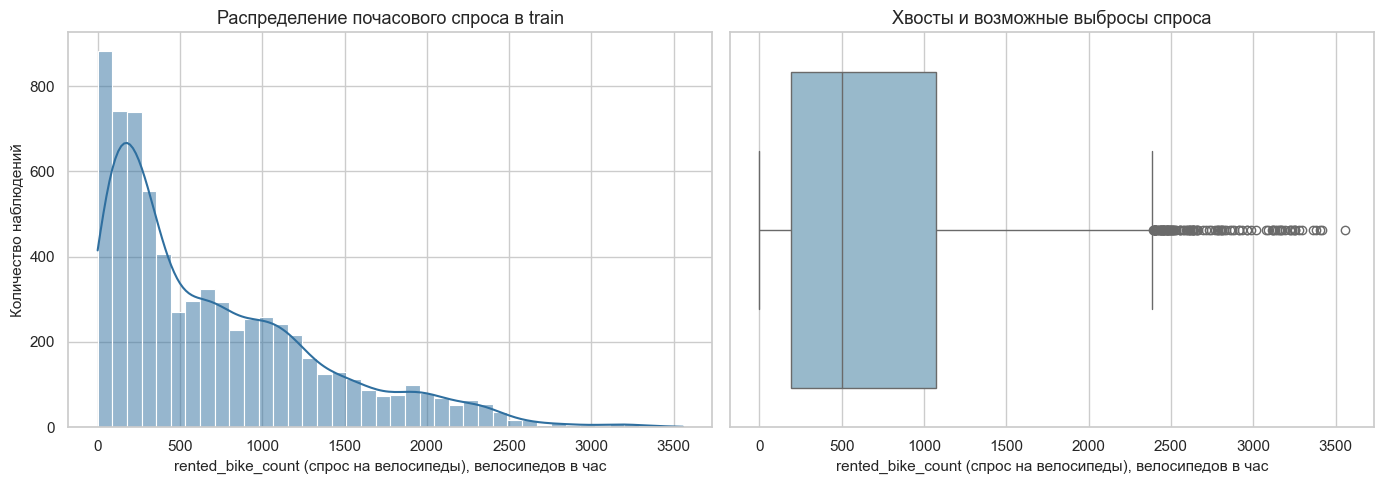

,train_target
count,"7,008.0000"
mean,705.6060
std,646.3118
min,0.0000
1%,0.0000
5%,22.0000
25%,190.7500
50%,504.5000
75%,"1,070.0000"
95%,"2,053.6000"


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET], bins=40, kde=True, ax=axes[0], color="#2f6f9f")
axes[0].set_title("Распределение почасового спроса в train")
axes[0].set_xlabel(inline_feature_label(TARGET, with_unit=True))
axes[0].set_ylabel("Количество наблюдений")

sns.boxplot(x=train[TARGET], ax=axes[1], color="#8fbcd4")
axes[1].set_title("Хвосты и возможные выбросы спроса")
axes[1].set_xlabel(inline_feature_label(TARGET, with_unit=True))
plt.tight_layout()
plt.show()

target_summary = train[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("train_target")
display(target_summary)


**Подвывод по target:** спрос перекошен вправо: большинство часов спокойные, но есть настоящие пики. Удалять их как выбросы нельзя - именно в такие часы прокату важнее всего не ошибиться. Поэтому оставляю пики в данных и выбираю `RMSE` как основную метрику: она сильнее штрафует крупные промахи.


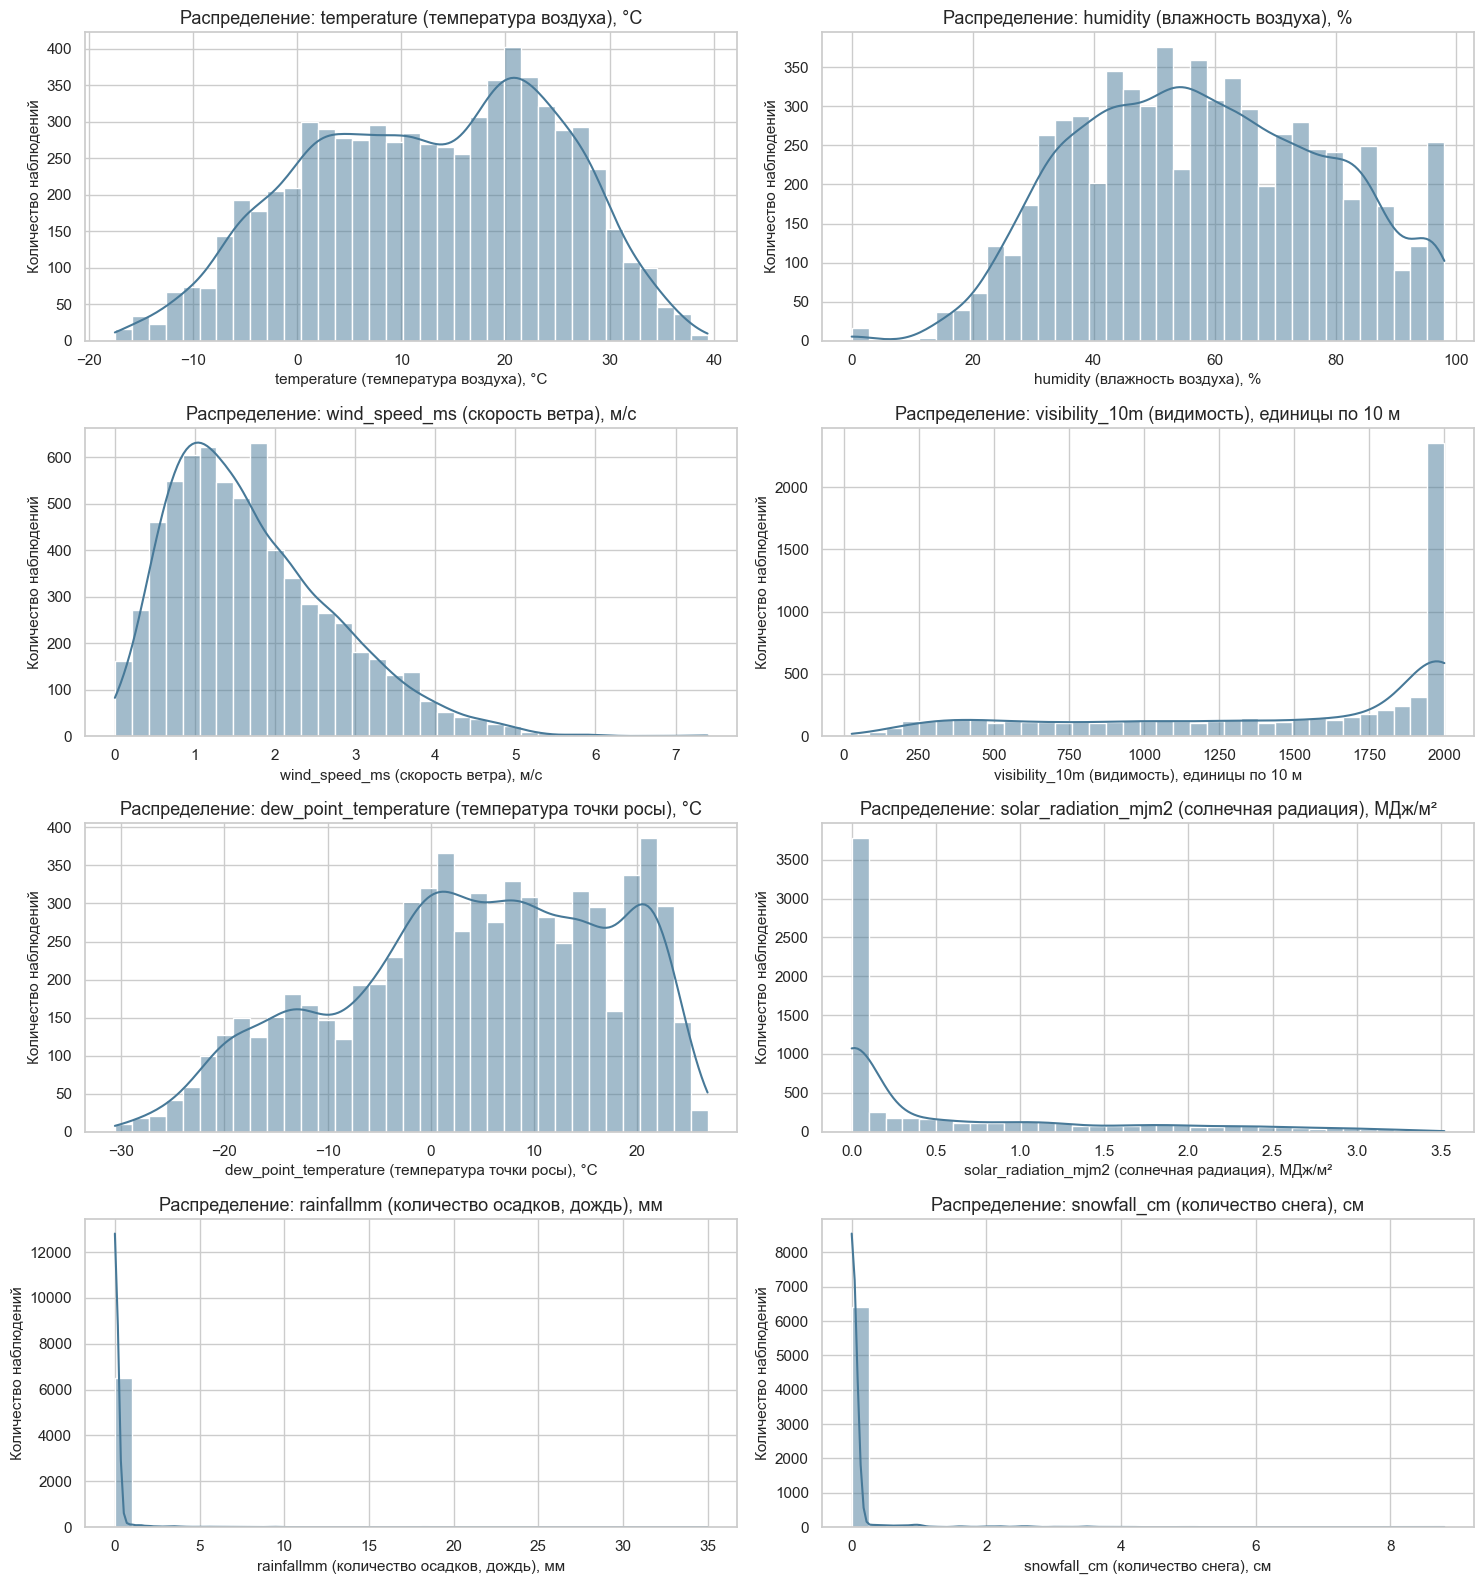

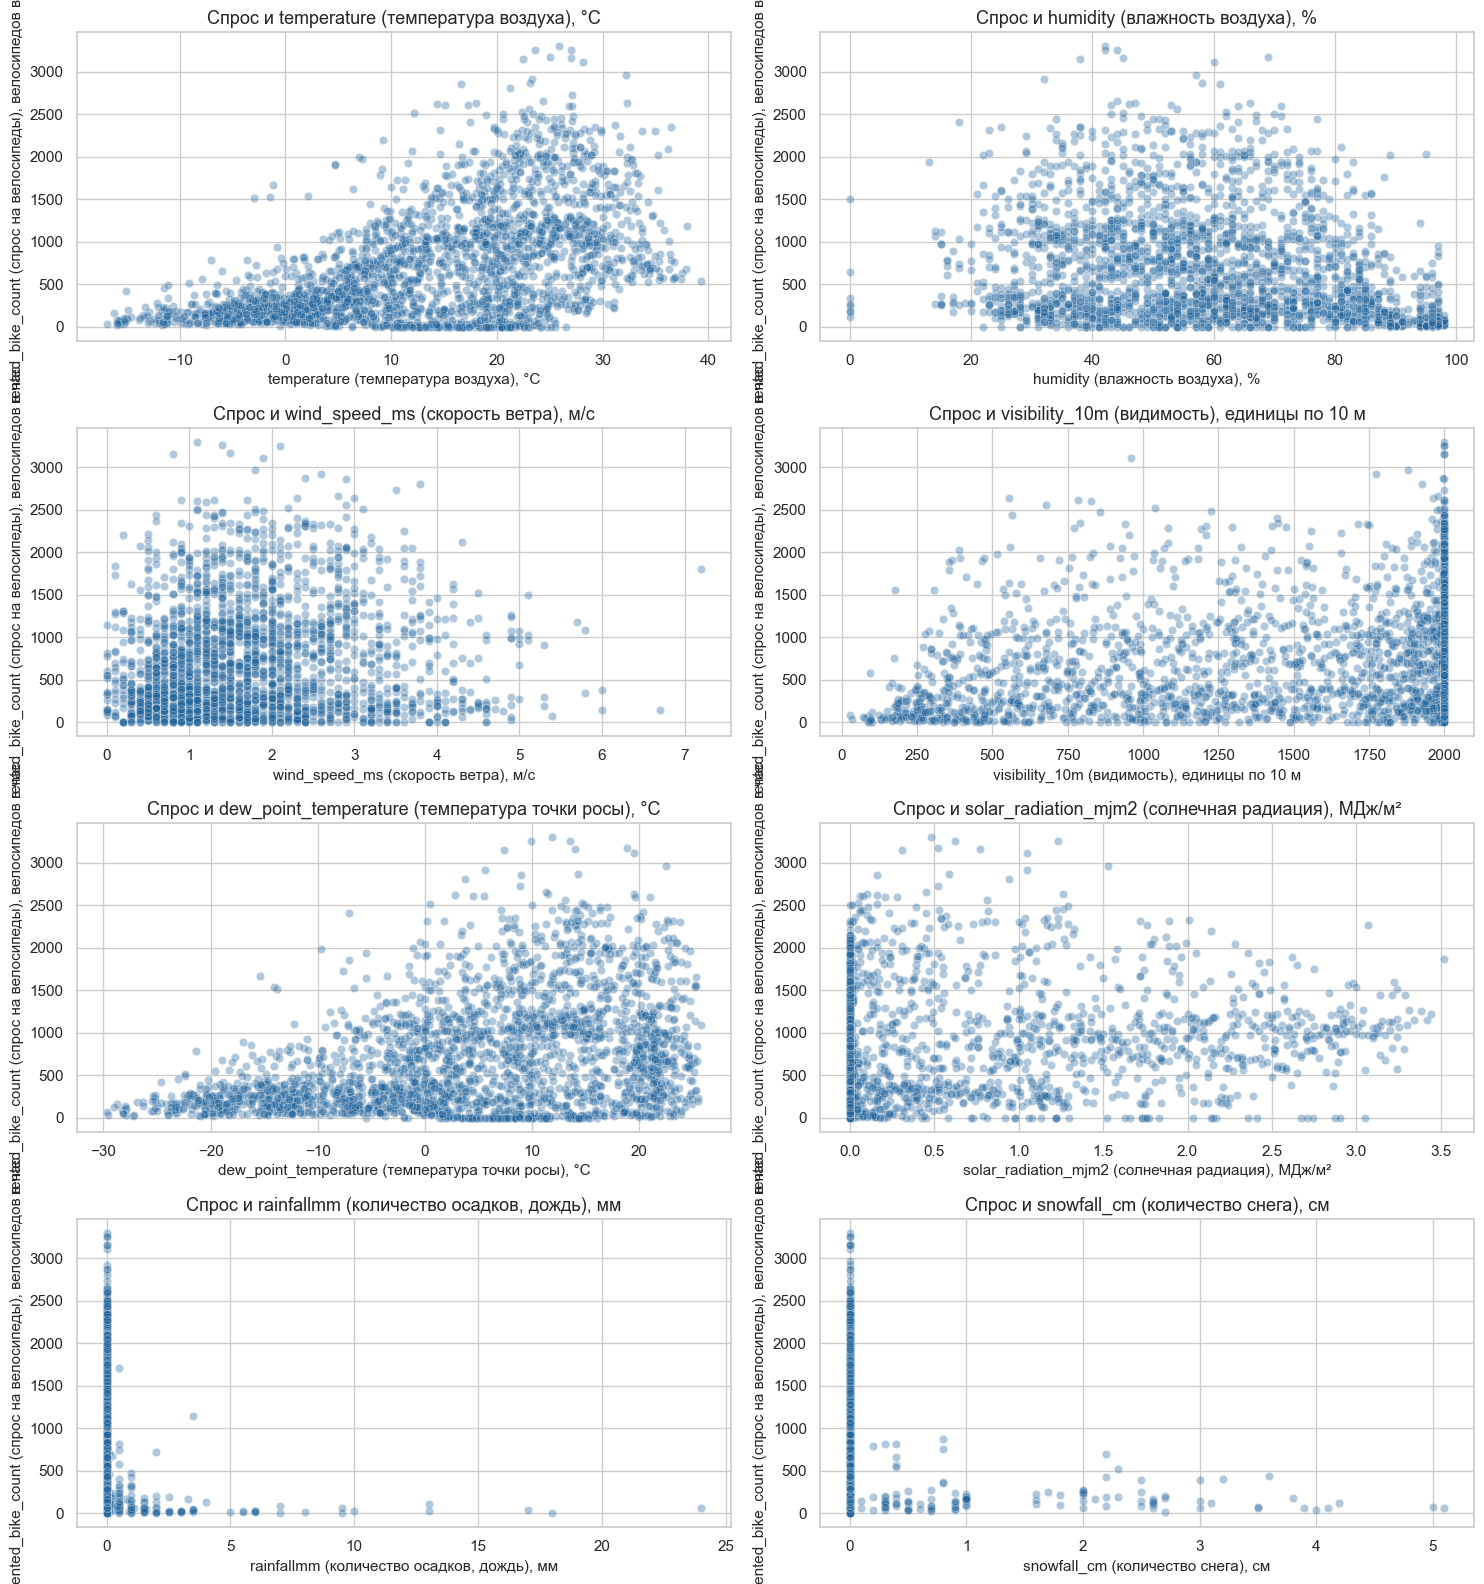

,feature,feature_label,spearman_corr_with_target,abs_spearman_corr
0,temperature,"temperature (температура воздуха), °C",0.5668,0.5668
1,dew_point_temperature,"dew_point_temperature (температура точки росы), °C",0.3810,0.3810
2,solar_radiation_mjm2,"solar_radiation_mjm2 (солнечная радиация), МДж/м²",0.3785,0.3785
3,rainfallmm,"rainfallmm (количество осадков, дождь), мм",-0.2739,0.2739
4,snowfall_cm,"snowfall_cm (количество снега), см",-0.2251,0.2251
5,humidity,"humidity (влажность воздуха), %",-0.2120,0.2120
6,visibility_10m,"visibility_10m (видимость), единицы по 10 м",0.1739,0.1739
7,wind_speed_ms,"wind_speed_ms (скорость ветра), м/с",0.1385,0.1385


In [8]:
continuous_labels = {
    column: inline_feature_label(column, with_unit=True)
    for column in BASE_NUMERIC_FEATURES
}

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()
for ax, column in zip(axes, BASE_NUMERIC_FEATURES):
    sns.histplot(train[column], bins=35, kde=True, ax=ax, color="#477998")
    ax.set_title(f"Распределение: {continuous_labels[column]}")
    ax.set_xlabel(continuous_labels[column])
    ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()
sampled_train = train.sample(min(2500, len(train)), random_state=RANDOM_STATE)
for ax, column in zip(axes, BASE_NUMERIC_FEATURES):
    sns.scatterplot(data=sampled_train, x=column, y=TARGET, alpha=0.35, ax=ax, color="#20639b")
    ax.set_title(f"Спрос и {continuous_labels[column]}")
    ax.set_xlabel(continuous_labels[column])
    ax.set_ylabel(inline_feature_label(TARGET, with_unit=True))
plt.tight_layout()
plt.show()

numeric_corr = (
    train[BASE_NUMERIC_FEATURES + [TARGET]]
    .corr(method="spearman", numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", TARGET: "spearman_corr_with_target"})
)
numeric_corr["abs_spearman_corr"] = numeric_corr["spearman_corr_with_target"].abs()
numeric_corr["feature_label"] = numeric_corr["feature"].map(lambda value: inline_feature_label(value, with_unit=True))
display(numeric_corr[["feature", "feature_label", "spearman_corr_with_target", "abs_spearman_corr"]])


**Как читать Spearman:** коэффициент Спирмена смотрит не на прямую линию, а на монотонную связь рангов. Значение ближе к `+1` означает: чем больше признак, тем чаще выше спрос. Значение ближе к `-1` означает обратную связь. Около `0` - устойчивого монотонного порядка почти нет. Это не доказательство причины, но хороший ранний индикатор, какие погодные признаки стоит проверить в нелинейной модели.


**Подвывод по погодным признакам:** Spearman нужен здесь как грубый компас, а не как финальное доказательство. Он показывает, что спрос заметнее всего меняется вместе с `temperature` (температура воздуха), `dew_point_temperature` (температура точки росы), `solar_radiation_mjm2` (солнечная радиация) и `humidity` (влажность воздуха). При этом scatter-графики не похожи на одну прямую: одинаковые `+28 °C` после дождя и под солнцем могут давать разный спрос. Поэтому KNN/tree здесь уместны, а погодные взаимодействия добавляются не ради усложнения, а чтобы поймать такие сочетания.


,feature,value,count,mean_demand,median_demand
0,seasons,Summer,1744,"1,046.2471",923.0000
1,seasons,Autumn,1770,820.6441,764.0000
2,seasons,Spring,1758,725.0461,578.5000
3,seasons,Winter,1736,226.4176,204.0000
4,holiday,No Holiday,6668,716.4019,524.0000
5,holiday,Holiday,340,493.8794,228.5000
6,functioning_day,Yes,6766,730.8435,546.0000
7,functioning_day,No,242,0.0000,0.0000
8,time_period_evening,True,1168,"1,193.9795","1,154.0000"
9,time_period_evening,False,5840,607.9313,422.0000


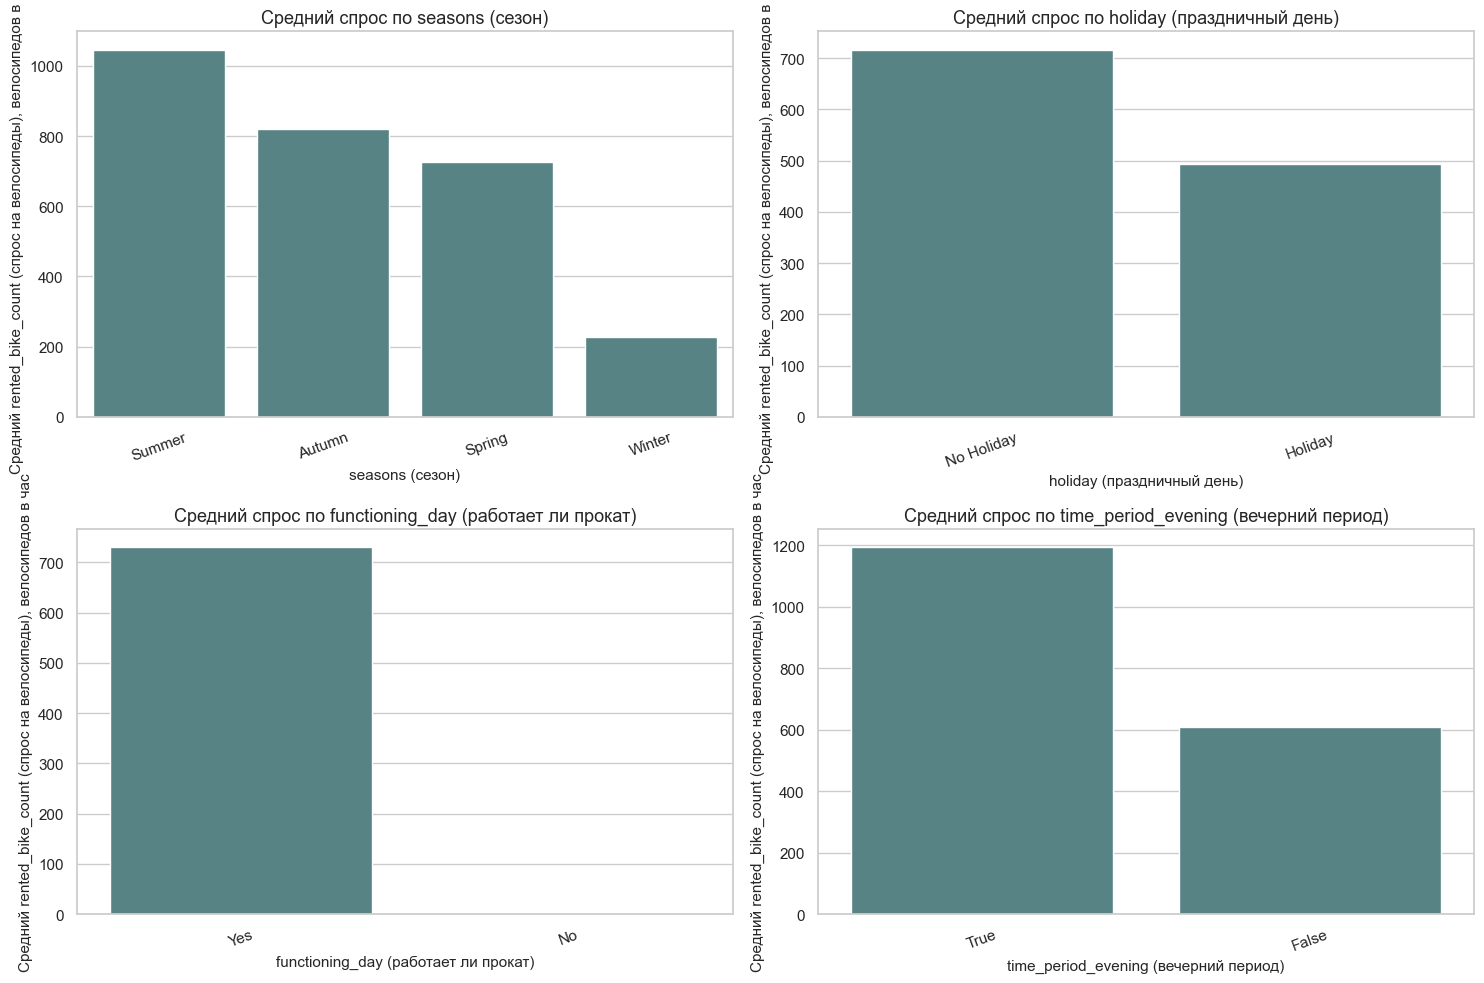

In [9]:
cat_target_tables = []
for column in CATEGORICAL_FEATURES + TIME_FEATURES:
    summary = (
        train.groupby(column, dropna=False)[TARGET]
        .agg(count="count", mean_demand="mean", median_demand="median")
        .reset_index()
        .sort_values("mean_demand", ascending=False)
    )
    summary.insert(0, "feature", column)
    cat_target_tables.append(summary.rename(columns={column: "value"}))

cat_target_summary = pd.concat(cat_target_tables, ignore_index=True)
display(cat_target_summary)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_columns = ["seasons", "holiday", "functioning_day", "time_period_evening"]
for ax, column in zip(axes.ravel(), plot_columns):
    order = train.groupby(column)[TARGET].mean().sort_values(ascending=False).index
    sns.barplot(data=train, x=column, y=TARGET, order=order, estimator="mean", errorbar=None, ax=ax, color="#4f8a8b")
    ax.set_title(f"Средний спрос по {inline_feature_label(column)}")
    ax.set_xlabel(inline_feature_label(column))
    ax.set_ylabel(f"Средний {inline_feature_label(TARGET, with_unit=True)}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**Подвывод по категориальным и временным признакам:** `functioning_day` нельзя обрабатывать как обычную категорию без смысла. Если прокат закрыт, нулевой спрос ожидаем. Если прокат открыт и спрос нулевой, это уже другая ситуация. Time-period признаки тоже важны: утро, вечер и ночь описывают разные сценарии нагрузки. Скрытый `Daytime` восстанавливается как строка, где все четыре time-period dummy равны `False`.


In [10]:
eda_decisions = pd.DataFrame(
    [
        {
            "EDA observation": "Погодные числовые признаки имеют пропуски, но доля пропусков ограничена.",
            "Modeling decision": "Не удалять строки; использовать SimpleImputer(strategy='median') внутри pipeline.",
        },
        {
            "EDA observation": "Категориальные признаки имеют небольшое число уровней.",
            "Modeling decision": "Использовать SimpleImputer(strategy='most_frequent') и OneHotEncoder(handle_unknown='ignore', drop='first').",
        },
        {
            "EDA observation": "Time_Period_Daytime скрыт как строка, где все time-period dummy равны False.",
            "Modeling decision": "Добавить `time_period_daytime` в кастомном transformer.",
        },
        {
            "EDA observation": "Температура, влажность, солнечная радиация и осадки связаны со спросом нелинейно.",
            "Modeling decision": "Обучить KNN и Decision Tree; добавить weather interaction признаки.",
        },
        {
            "EDA observation": "Baseline линейной регрессии дает отрицательные прогнозы.",
            "Modeling decision": "Проверять диапазон предсказаний финальной модели и считать negative_predictions.",
        },
        {
            "EDA observation": "Хвосты спроса выглядят как реальные пики, а не технические ошибки.",
            "Modeling decision": "Не удалять target outliers механически; оценивать RMSE и MAE вместе.",
        },
    ]
)
display(eda_decisions)


,EDA observation,Modeling decision
0,"Погодные числовые признаки имеют пропуски, но доля пропусков ограничена.",Не удалять строки; использовать SimpleImputer(strategy='median') внутри pipeline.
1,Категориальные признаки имеют небольшое число уровней.,"Использовать SimpleImputer(strategy='most_frequent') и OneHotEncoder(handle_unknown='ignore', drop='first')."
2,"Time_Period_Daytime скрыт как строка, где все time-period dummy равны False.",Добавить `time_period_daytime` в кастомном transformer.
3,"Температура, влажность, солнечная радиация и осадки связаны со спросом нелинейно.",Обучить KNN и Decision Tree; добавить weather interaction признаки.
4,Baseline линейной регрессии дает отрицательные прогнозы.,Проверять диапазон предсказаний финальной модели и считать negative_predictions.
5,"Хвосты спроса выглядят как реальные пики, а не технические ошибки.",Не удалять target outliers механически; оценивать RMSE и MAE вместе.


**Вывод этапа 4:** EDA дал конкретный план для модели: пропуски заполнять внутри pipeline, пики спроса не выкидывать, `Daytime` восстановить, погодные взаимодействия добавить, отрицательные прогнозы контролировать отдельно. Это не набор косметических правок, а защита от типичных ошибок в этой задаче.


<a id="stage-5"></a>
## Этап 5. Pipeline и feature engineering

Теперь решения из EDA превращаются в один pipeline. Важная идея: снаружи pipeline получает сырые признаки, а внутри сам делает все нужные шаги - добавляет признаки, заполняет пропуски, кодирует категории и обучает модель. Так меньше риска забыть какой-то шаг при повторном запуске или инференсе.

Дополнительный пункт закрывается отдельным инженерным решением: кастомный `BikeFeatureEngineer` сделан как sklearn-compatible transformer с методами `fit` и `transform`. Он делает только безопасные вещи: восстанавливает `time_period_daytime` (дневной период), добавляет флаги осадков и погодные взаимодействия. Target он не видит. Transformer вынесен в `bike_demand_pipeline_components.py`, чтобы сохраненный `joblib` открывался в чистом Python-процессе.


In [11]:
from bike_demand_pipeline_components import (
    BikeFeatureEngineer,
    CATEGORICAL_FEATURES,
    ENGINEERED_FEATURES,
    MODEL_FEATURES_AFTER_ENGINEERING,
    NUMERIC_WITH_ENGINEERED,
)


def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps: List[Tuple[str, Any]] = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_WITH_ENGINEERED),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def make_model_pipeline(model: BaseEstimator, scale_numeric: bool) -> Pipeline:
    return Pipeline(
        steps=[
            ("feature_engineering", BikeFeatureEngineer()),
            ("preprocessor", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", model),
        ]
    )


schema_check = BikeFeatureEngineer().fit_transform(X_train.head(5))
display(schema_check)
assert list(schema_check.columns) == MODEL_FEATURES_AFTER_ENGINEERING
assert schema_check.shape[1] == len(MODEL_FEATURES_AFTER_ENGINEERING)

additional_task_closure = pd.DataFrame(
    [
        {
            "reviewer_requirement": "Добавить собственную обработку признаков в стиле sklearn.",
            "implementation": "`BikeFeatureEngineer` наследуется от `BaseEstimator` и `TransformerMixin`, имеет `fit`/`transform` и возвращает стабильную схему колонок.",
            "where_checked": "`schema_check`, `MODEL_FEATURES_AFTER_ENGINEERING`, reload сохраненного `joblib`.",
        },
        {
            "reviewer_requirement": "Feature engineering должен быть частью pipeline, а не ручной подготовкой перед обучением.",
            "implementation": "Первый шаг каждого нового pipeline - `('feature_engineering', BikeFeatureEngineer())`; дальше идут imputer/encoder/scaler и модель.",
            "where_checked": "`make_model_pipeline`, `production_contract`, `artifact_manifest`.",
        },
        {
            "reviewer_requirement": "Новые признаки должны иметь смысл для задачи.",
            "implementation": "Добавлены `time_period_daytime` (дневной период), `rainfall_flag` (наличие дождя), `snowfall_flag` (наличие снега), `dew_point_gap` (разница температуры и точки росы), `comfort_temperature` (комфортный диапазон температуры), `low_visibility_flag` (низкая видимость), `temperature_x_humidity` и `temperature_x_solar` (погодные взаимодействия).",
            "where_checked": "EDA-решения, список `ENGINEERED_FEATURES`, importance финальной модели.",
        },
        {
            "reviewer_requirement": "Сохраненная модель должна открываться вне ноутбука.",
            "implementation": "Класс transformer лежит в импортируемом модуле `bike_demand_pipeline_components.py`, модуль включен в manifest и проверен checksum.",
            "where_checked": "`joblib.load`, `component_symbol_check`, `artifact_inventory`.",
        },
    ]
)
display(additional_task_closure)


,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,dew_point_gap,has_rain,has_snow,has_precipitation,comfortable_temperature,freezing_weather,hot_weather,hot_and_humid,temp_x_solar,temp_x_humidity,rain_x_wind,snow_x_freezing,time_period_daytime,seasons,holiday,functioning_day
0,20.3000,35.0000,2.4000,"2,000.0000",4.3000,0.4600,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,16.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,9.3380,710.5000,0.0000,0.0000,0.0000,Autumn,Holiday,Yes
1,25.4000,55.0000,3.2000,"2,000.0000",15.6000,0.1500,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,9.8000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,3.8100,"1,397.0000",0.0000,0.0000,0.0000,Autumn,No Holiday,Yes
2,-6.9000,39.0000,1.6000,"2,000.0000",-18.5000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.6000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,-269.1000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes
3,-5.2000,37.0000,2.2000,"2,000.0000",-17.6000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,12.4000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,-192.4000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes
4,23.4000,34.0000,2.1000,"2,000.0000",6.6000,2.8400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.8000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,66.4560,795.6000,0.0000,0.0000,1.0000,Autumn,No Holiday,Yes


,reviewer_requirement,implementation,where_checked
0,Добавить собственную обработку признаков в стиле sklearn.,"`BikeFeatureEngineer` наследуется от `BaseEstimator` и `TransformerMixin`, имеет `fit`/`transform` и возвращает стабильную схему колонок.","`schema_check`, `MODEL_FEATURES_AFTER_ENGINEERING`, reload сохраненного `joblib`."
1,"Feature engineering должен быть частью pipeline, а не ручной подготовкой перед обучением.","Первый шаг каждого нового pipeline - `('feature_engineering', BikeFeatureEngineer())`; дальше идут imputer/encoder/scaler и модель.","`make_model_pipeline`, `production_contract`, `artifact_manifest`."
2,Новые признаки должны иметь смысл для задачи.,"Добавлены `time_period_daytime` (дневной период), `rainfall_flag` (наличие дождя), `snowfall_flag` (наличие снега), `dew_point_gap` (разница температуры и точки росы), `comfort_temperature` (комфортный диапазон температуры), `low_visibility_flag` (низкая видимость), `temperature_x_humidity` и `temperature_x_solar` (погодные взаимодействия).","EDA-решения, список `ENGINEERED_FEATURES`, importance финальной модели."
3,Сохраненная модель должна открываться вне ноутбука.,"Класс transformer лежит в импортируемом модуле `bike_demand_pipeline_components.py`, модуль включен в manifest и проверен checksum.","`joblib.load`, `component_symbol_check`, `artifact_inventory`."


**Подвывод по pipeline:** дополнительный пункт закрыт не косметически, а через полноценный transformer внутри sklearn pipeline. Схема остается простой: сначала `BikeFeatureEngineer`, потом общий препроцессинг, потом модель. KNN получает масштабированные числовые признаки, потому что расстояния чувствительны к масштабу. Дереву масштабирование не нужно: оно режет признаки по порогам.


<a id="stage-6"></a>
## Этап 6. Optuna и 5-fold CV

Здесь сравниваются не отдельные алгоритмы "на глаз", а полные pipeline. Это важно: качество KNN и дерева считается вместе с теми же правилами обработки пропусков, категорий и инженерных признаков, которые потом попадут в финальную модель.

`DummyRegressor` нужен как нижняя планка. После него Optuna подбирает параметры KNN и дерева. Для всех моделей используется одна и та же 5-fold CV, поэтому разница в метриках объясняется моделью и параметрами, а не разным протоколом проверки.


In [12]:
cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


def summarize_cv_scores(model_name: str, scores: Dict[str, np.ndarray], params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    return {
        "model": model_name,
        "cv_RMSE_mean": -float(scores["test_rmse"].mean()),
        "cv_RMSE_std": float(scores["test_rmse"].std()),
        "cv_MAE_mean": -float(scores["test_mae"].mean()),
        "cv_R2_mean": float(scores["test_r2"].mean()),
        "fit_time_mean_sec": float(scores["fit_time"].mean()),
        "score_time_mean_sec": float(scores["score_time"].mean()),
        "params": params or {},
    }


def cross_validate_pipeline(model_name: str, pipeline: Pipeline, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    return summarize_cv_scores(model_name, scores, params=params)


dummy_pipeline = Pipeline(steps=[("model", DummyRegressor(strategy="mean"))])
dummy_cv_result = cross_validate_pipeline("dummy_mean", dummy_pipeline)
display(pd.DataFrame([dummy_cv_result]).drop(columns="params"))


,model,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_R2_mean,fit_time_mean_sec,score_time_mean_sec
0,dummy_mean,646.3462,6.3640,521.1947,-0.0010,0.0014,0.0020


**Подвывод по DummyRegressor:** dummy просто предсказывает средний спрос. Это полезная проверка здравого смысла: если более сложная модель не обгоняет среднее, значит признаки или pipeline не работают.


In [13]:
def objective_knn(trial: optuna.Trial) -> float:
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 80),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2),
        "leaf_size": trial.suggest_int("leaf_size", 10, 60),
    }
    pipeline = make_model_pipeline(KNeighborsRegressor(**params), scale_numeric=True)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    trial.set_user_attr("mae", -float(scores["test_mae"].mean()))
    trial.set_user_attr("r2", float(scores["test_r2"].mean()))
    trial.set_user_attr("rmse_std", float(scores["test_rmse"].std()))
    return -float(scores["test_rmse"].mean())


def objective_tree(trial: optuna.Trial) -> float:
    params = {
        "max_depth": trial.suggest_categorical("max_depth", [None, 3, 5, 7, 10, 15, 20, 30]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2", 0.5, 0.8, 1.0]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-8, 1e-2, log=True),
        "random_state": RANDOM_STATE,
    }
    pipeline = make_model_pipeline(DecisionTreeRegressor(**params), scale_numeric=False)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    trial.set_user_attr("mae", -float(scores["test_mae"].mean()))
    trial.set_user_attr("r2", float(scores["test_r2"].mean()))
    trial.set_user_attr("rmse_std", float(scores["test_rmse"].std()))
    return -float(scores["test_rmse"].mean())


study_timings = {}

start = time.perf_counter()
knn_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
knn_study.optimize(objective_knn, n_trials=N_TRIALS_KNN, show_progress_bar=False)
study_timings["KNN"] = time.perf_counter() - start

start = time.perf_counter()
tree_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
tree_study.optimize(objective_tree, n_trials=N_TRIALS_TREE, show_progress_bar=False)
study_timings["DecisionTree"] = time.perf_counter() - start

study_summary = pd.DataFrame(
    [
        {
            "model": "KNN",
            "trials": len(knn_study.trials),
            "best_RMSE": knn_study.best_value,
            "best_MAE": knn_study.best_trial.user_attrs["mae"],
            "best_R2": knn_study.best_trial.user_attrs["r2"],
            "best_RMSE_std": knn_study.best_trial.user_attrs["rmse_std"],
            "time_sec": study_timings["KNN"],
            "best_params": knn_study.best_params,
        },
        {
            "model": "DecisionTree",
            "trials": len(tree_study.trials),
            "best_RMSE": tree_study.best_value,
            "best_MAE": tree_study.best_trial.user_attrs["mae"],
            "best_R2": tree_study.best_trial.user_attrs["r2"],
            "best_RMSE_std": tree_study.best_trial.user_attrs["rmse_std"],
            "time_sec": study_timings["DecisionTree"],
            "best_params": tree_study.best_params,
        },
    ]
)
display(study_summary)


  File "D:\DS\13\ml-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,model,trials,best_RMSE,best_MAE,best_R2,best_RMSE_std,time_sec,best_params
0,KNN,35,319.2453,212.4093,0.7557,8.9502,23.7242,"{'n_neighbors': 9, 'weights': 'distance', 'p': 1, 'leaf_size': 10}"
1,DecisionTree,45,315.8830,210.8592,0.7608,8.6112,16.6274,"{'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07}"


**Как читать подбор параметров:** у KNN главный рычаг - `n_neighbors`: мало соседей дает более резкую модель, много соседей сильнее сглаживает спрос. `weights="distance"` делает ближайшие часы более важными. У дерева главные ограничения - `max_depth`, `min_samples_leaf` и `min_samples_split`: они не дают дереву запомнить отдельные строки train.

Поэтому дальше сравниваются не все trials Optuna, а лучшие найденные версии KNN и дерева по одному и тому же CV-протоколу.


,model,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_R2_mean,fit_time_mean_sec,score_time_mean_sec
2,decision_tree_optuna,315.8830,8.6112,210.8592,0.7608,0.0913,0.0345
1,knn_optuna,319.2453,8.9502,212.4093,0.7557,0.0466,0.1169
0,dummy_mean,646.3462,6.3640,521.1947,-0.0010,0.0014,0.0020


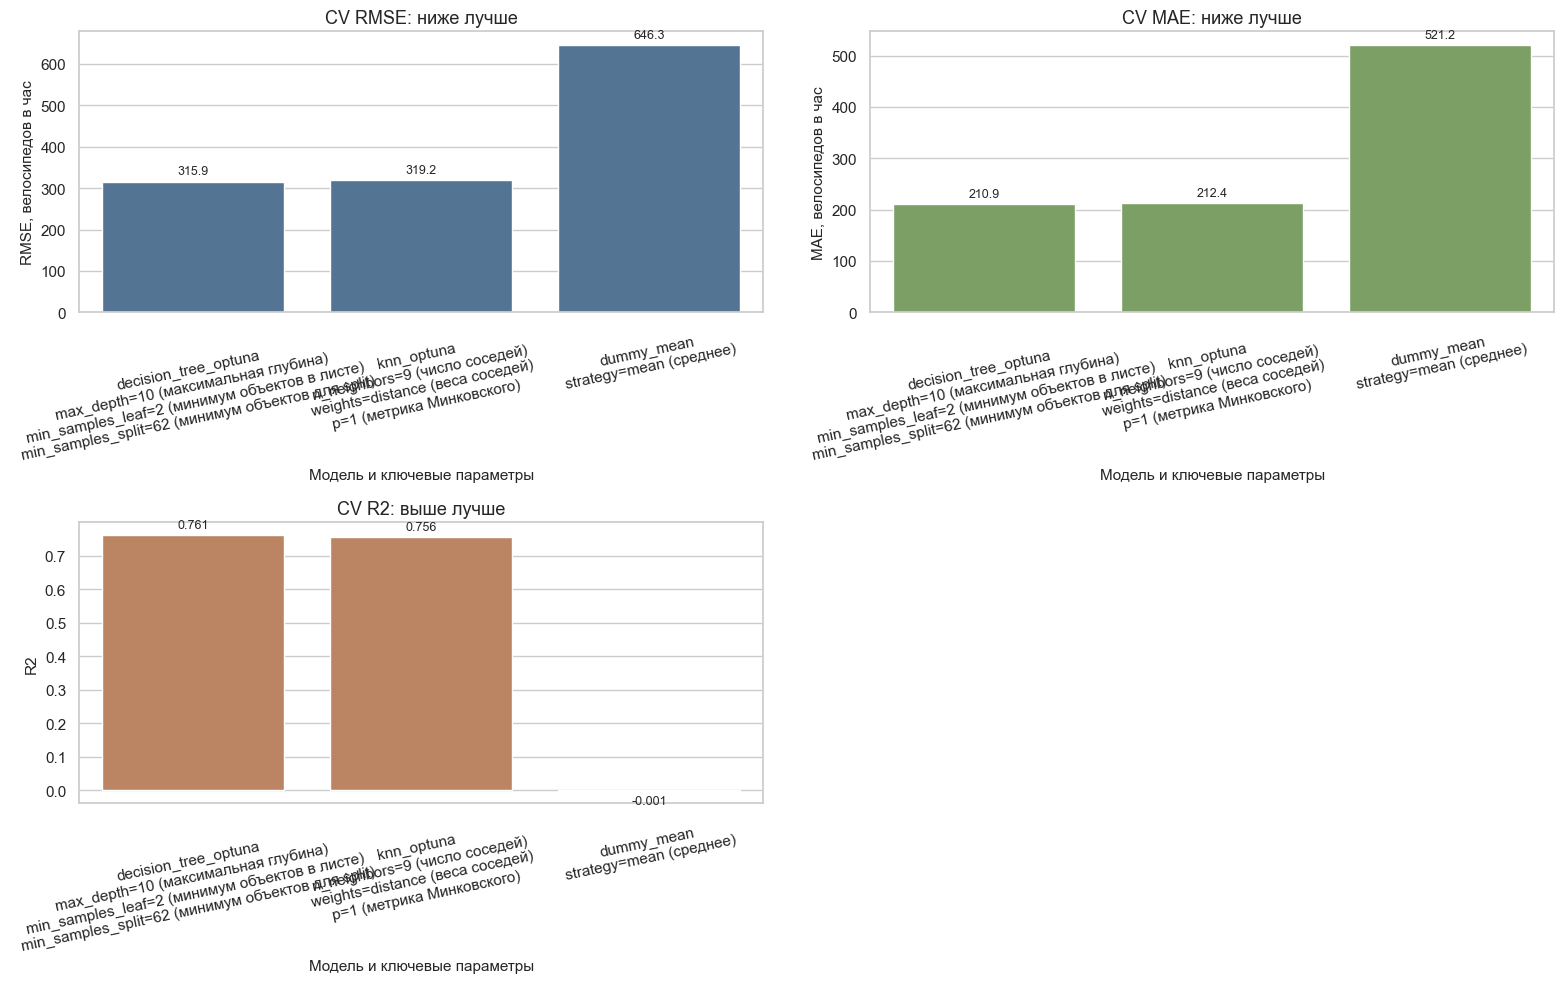

In [14]:
knn_best_pipeline = make_model_pipeline(KNeighborsRegressor(**knn_study.best_params), scale_numeric=True)
tree_best_params = dict(tree_study.best_params)
tree_best_params["random_state"] = RANDOM_STATE
tree_best_pipeline = make_model_pipeline(DecisionTreeRegressor(**tree_best_params), scale_numeric=False)

cv_results = [dummy_cv_result]
cv_results.append(cross_validate_pipeline("knn_optuna", knn_best_pipeline, params=knn_study.best_params))
cv_results.append(cross_validate_pipeline("decision_tree_optuna", tree_best_pipeline, params=tree_best_params))

cv_comparison = pd.DataFrame(cv_results).sort_values("cv_RMSE_mean")
display(cv_comparison.drop(columns="params"))

plot_df = cv_comparison.copy()
plot_df["model_label"] = [
    f"{model}\n{short_params_for_plot(model, params)}"
    for model, params in zip(plot_df["model"], plot_df["params"])
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
sns.barplot(data=plot_df, x="model_label", y="cv_RMSE_mean", ax=axes[0], color="#49759c")
axes[0].set_title("CV RMSE: ниже лучше")
axes[0].set_xlabel("Модель и ключевые параметры")
axes[0].set_ylabel("RMSE, велосипедов в час")
axes[0].tick_params(axis="x", rotation=12)
add_bar_labels(axes[0], "%.1f")

sns.barplot(data=plot_df, x="model_label", y="cv_MAE_mean", ax=axes[1], color="#7aa95c")
axes[1].set_title("CV MAE: ниже лучше")
axes[1].set_xlabel("Модель и ключевые параметры")
axes[1].set_ylabel("MAE, велосипедов в час")
axes[1].tick_params(axis="x", rotation=12)
add_bar_labels(axes[1], "%.1f")

sns.barplot(data=plot_df, x="model_label", y="cv_R2_mean", ax=axes[2], color="#c98256")
axes[2].set_title("CV R2: выше лучше")
axes[2].set_xlabel("Модель и ключевые параметры")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis="x", rotation=12)
add_bar_labels(axes[2], "%.3f")
axes[3].axis("off")
plt.tight_layout()
plt.show()


In [15]:
def check_boundary_params(study: optuna.Study, model_name: str) -> pd.DataFrame:
    best = study.best_params
    if model_name == "KNN":
        ranges = {"n_neighbors": (3, 80), "leaf_size": (10, 60), "p": (1, 2)}
    else:
        ranges = {"min_samples_split": (2, 80), "min_samples_leaf": (1, 50)}
    rows = []
    for param, (low, high) in ranges.items():
        value = best.get(param)
        rows.append(
            {
                "model": model_name,
                "param": param,
                "best_value": value,
                "search_low": low,
                "search_high": high,
                "on_boundary": value in {low, high},
            }
        )
    return pd.DataFrame(rows)


boundary_check = pd.concat(
    [
        check_boundary_params(knn_study, "KNN"),
        check_boundary_params(tree_study, "DecisionTree"),
    ],
    ignore_index=True,
)
display(boundary_check)


,model,param,best_value,search_low,search_high,on_boundary
0,KNN,n_neighbors,9,3,80,False
1,KNN,leaf_size,10,10,60,True
2,KNN,p,1,1,2,True
3,DecisionTree,min_samples_split,62,2,80,False
4,DecisionTree,min_samples_leaf,2,1,50,False


**Вывод этапа 6:** модель выбирается по среднему `RMSE` на 5-fold CV. Рядом оставлены `MAE`, `R2`, разброс по фолдам и проверка границ Optuna. Это нужно, чтобы не выбрать модель из-за одного удачного фолда или слишком узкого диапазона параметров.


<a id="stage-7"></a>
## Этап 7. Финальная проверка на test

Теперь модель уже выбрана. Я обучаю ее на всем train и один раз применяю к test. До этого test не участвовал ни в Optuna, ни в выборе модели.


In [16]:
best_cv_row = cv_comparison.iloc[0]
best_model_name = best_cv_row["model"]

if best_model_name == "knn_optuna":
    final_pipeline = knn_best_pipeline
    final_params = knn_study.best_params
elif best_model_name == "decision_tree_optuna":
    final_pipeline = tree_best_pipeline
    final_params = tree_best_params
else:
    raise RuntimeError("Dummy model should not be selected as final model")

final_pipeline.fit(X_train, y_train)
final_test_predictions = final_pipeline.predict(X_test)
final_train_predictions = final_pipeline.predict(X_train)

final_results = pd.DataFrame(
    [
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_test, y_test, "test"),
        {
            "model": best_model_name,
            "split": "test",
            **regression_metrics(y_test, final_test_predictions),
        },
        {
            "model": best_model_name,
            "split": "train_fit_reference",
            **regression_metrics(y_train, final_train_predictions),
        },
    ]
)

baseline_test_rmse = final_results.query("model == 'company_linear_baseline' and split == 'test'")["RMSE"].iloc[0]
final_test_rmse = final_results.query("model == @best_model_name and split == 'test'")["RMSE"].iloc[0]
rmse_improvement_pct = (baseline_test_rmse - final_test_rmse) / baseline_test_rmse * 100

display(final_results)
print(f"Выбранная модель: {best_model_name}")
print(f"Улучшение RMSE относительно baseline на test: {rmse_improvement_pct:.2f}%")
print(f"Параметры финальной модели: {final_params}")


,model,split,RMSE,MAE,R2,prediction_min,prediction_max,prediction_mean,negative_predictions
0,company_linear_baseline,test,411.4545,312.5313,0.5863,-715.2865,"1,963.7774",715.3055,147
1,decision_tree_optuna,test,310.7677,207.4268,0.7640,0.0000,"2,290.0652",708.1094,0
2,decision_tree_optuna,train_fit_reference,282.0789,187.1464,0.8095,0.0000,"2,290.0652",705.6060,0


Выбранная модель: decision_tree_optuna
Улучшение RMSE относительно baseline на test: 24.47%
Параметры финальной модели: {'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07, 'random_state': 42}


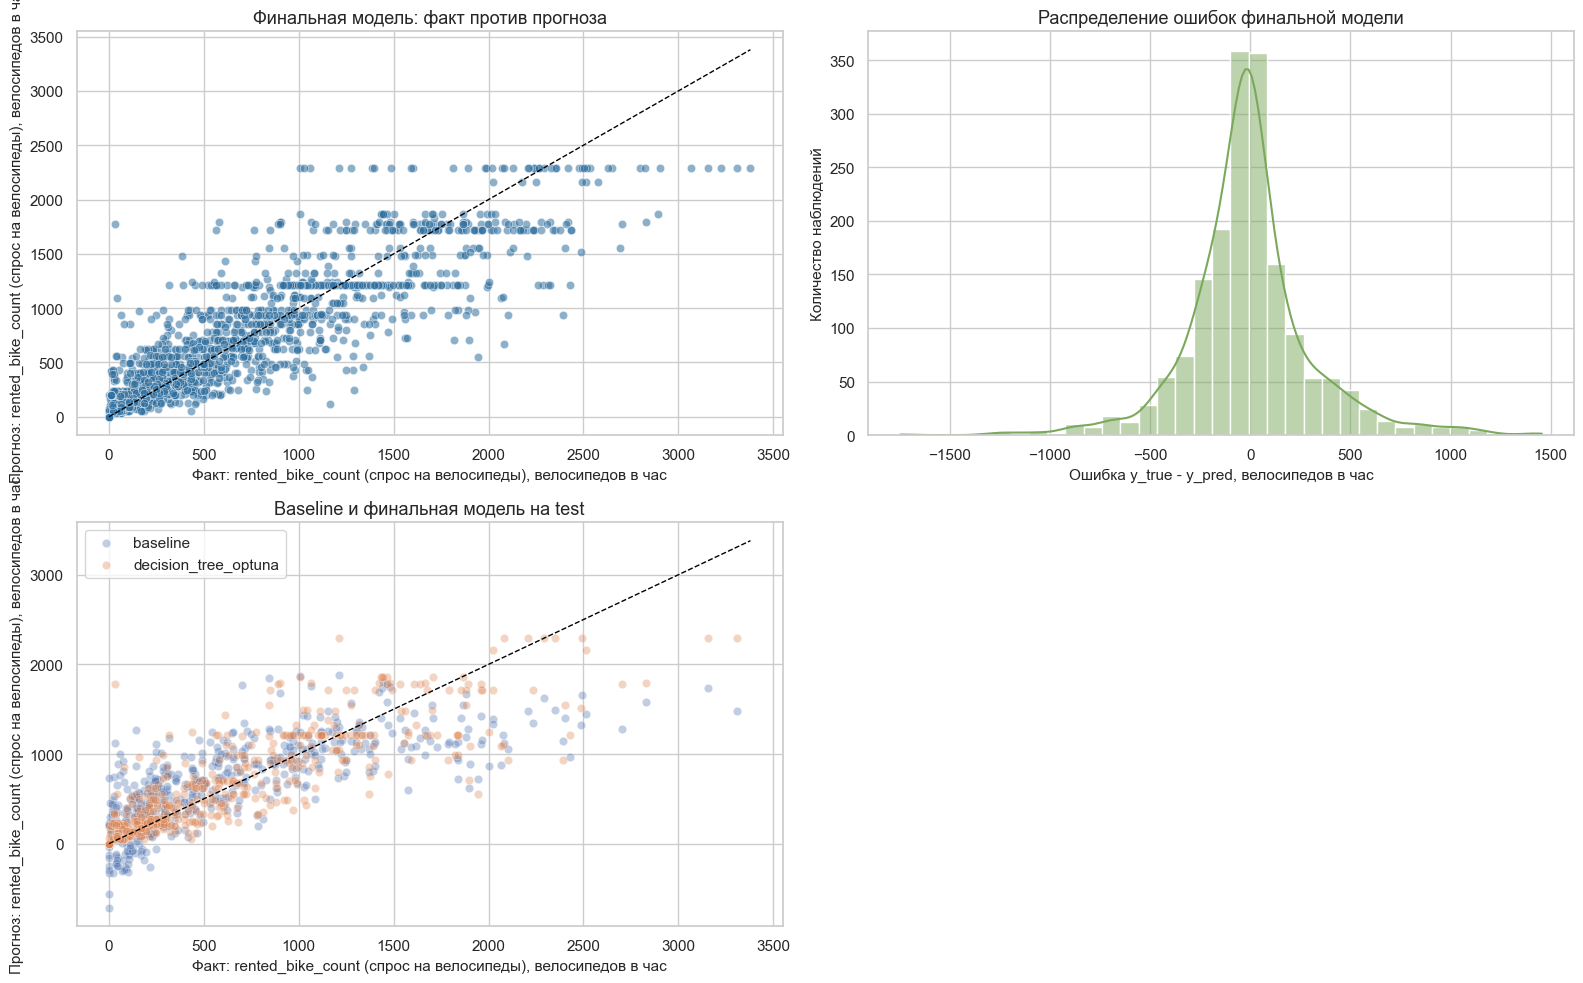

In [17]:
residuals = y_test - final_test_predictions
baseline_test_predictions = baseline_pipeline.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()
sns.scatterplot(x=y_test, y=final_test_predictions, alpha=0.55, ax=axes[0], color="#2f6f9f")
max_value = max(y_test.max(), final_test_predictions.max())
axes[0].plot([0, max_value], [0, max_value], color="black", linestyle="--", linewidth=1)
axes[0].set_title("Финальная модель: факт против прогноза")
axes[0].set_xlabel(f"Факт: {inline_feature_label(TARGET, with_unit=True)}")
axes[0].set_ylabel(f"Прогноз: {inline_feature_label(TARGET, with_unit=True)}")

sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="#7aa95c")
axes[1].set_title("Распределение ошибок финальной модели")
axes[1].set_xlabel("Ошибка y_true - y_pred, велосипедов в час")
axes[1].set_ylabel("Количество наблюдений")

comparison_plot = pd.DataFrame(
    {
        "actual": y_test,
        "baseline_prediction": baseline_test_predictions,
        "final_prediction": final_test_predictions,
    }
).sample(min(500, len(y_test)), random_state=RANDOM_STATE)
sns.scatterplot(data=comparison_plot, x="actual", y="baseline_prediction", alpha=0.35, label="baseline", ax=axes[2])
sns.scatterplot(data=comparison_plot, x="actual", y="final_prediction", alpha=0.35, label=best_model_name, ax=axes[2])
axes[2].plot([0, max_value], [0, max_value], color="black", linestyle="--", linewidth=1)
axes[2].set_title("Baseline и финальная модель на test")
axes[2].set_xlabel(f"Факт: {inline_feature_label(TARGET, with_unit=True)}")
axes[2].set_ylabel(f"Прогноз: {inline_feature_label(TARGET, with_unit=True)}")
axes[2].legend()
axes[3].axis("off")

plt.tight_layout()
plt.show()


In [18]:
baseline_final_row = final_results.query("model == 'company_linear_baseline' and split == 'test'").iloc[0]
selected_final_row = final_results.query("model == @best_model_name and split == 'test'").iloc[0]
test_rmse_delta = baseline_final_row["RMSE"] - selected_final_row["RMSE"]
test_mae_delta = baseline_final_row["MAE"] - selected_final_row["MAE"]
test_r2_delta = selected_final_row["R2"] - baseline_final_row["R2"]

display(
    Markdown(
        f"""
        **Расчетные итоги финальной test-проверки**

        - Baseline test RMSE: `{baseline_final_row["RMSE"]:.2f}`.
        - Final test RMSE: `{selected_final_row["RMSE"]:.2f}`.
        - Улучшение RMSE: `{test_rmse_delta:.2f}` велосипеда в час (`{rmse_improvement_pct:.2f}%`).
        - Улучшение MAE: `{test_mae_delta:.2f}` велосипеда в час.
        - Прирост R2: `{test_r2_delta:.3f}`.
        - Отрицательные прогнозы baseline/final: `{int(baseline_final_row["negative_predictions"])}` / `{int(selected_final_row["negative_predictions"])}`.
        """
    )
)



        **Расчетные итоги финальной test-проверки**

        - Baseline test RMSE: `411.45`.
        - Final test RMSE: `310.77`.
        - Улучшение RMSE: `100.69` велосипеда в час (`24.47%`).
        - Улучшение MAE: `105.10` велосипеда в час.
        - Прирост R2: `0.178`.
        - Отрицательные прогнозы baseline/final: `147` / `0`.
        

**Интерпретация финальной проверки:** на test новая модель ошибается заметно меньше baseline и не дает отрицательных прогнозов. Это уже можно показывать бизнесу как рабочий кандидат для пилота. Но это еще не промышленный запуск: сначала нужна проверка на более позднем периоде, где погода, сезон и поведение клиентов могли измениться.


<a id="stage-7-1"></a>
## Этап 7.1. Сегментный аудит против baseline

Средний `RMSE` отвечает на вопрос "стала ли модель лучше в среднем". Для проката этого мало. Нужно понять, где именно появляется выигрыш: в пиковом спросе, в дождь, ночью, по сезонам или только на простых часах. Ниже сравнение baseline и финальной модели в одинаковых test-сегментах. Сегменты пересекаются: это не одно разбиение выборки, а набор рабочих срезов для пилота и мониторинга.


In [19]:
segment_frame = X_test.copy()
segment_frame[TARGET] = y_test.to_numpy()
segment_frame["baseline_prediction"] = baseline_test_predictions
segment_frame["final_prediction"] = final_test_predictions

low_threshold, high_threshold = y_test.quantile([0.33, 0.66]).tolist()
segment_frame["demand_level"] = np.select(
    [
        y_test <= low_threshold,
        y_test <= high_threshold,
    ],
    [
        f"low <= {low_threshold:.0f} (низкий спрос)",
        f"medium {low_threshold:.0f}-{high_threshold:.0f} (средний спрос)",
    ],
    default=f"high > {high_threshold:.0f} (высокий спрос)",
)


def category_value_label(column: str, value: Any) -> str:
    value_text = str(value)
    description = FEATURE_DESCRIPTIONS_RU.get(f"{column}_{value_text}", value_text)
    return f"{value_text} ({description})" if description != value_text else value_text


segment_frame["season_segment"] = segment_frame["seasons"].map(lambda value: category_value_label("seasons", value))
segment_frame["holiday_segment"] = segment_frame["holiday"].map(lambda value: category_value_label("holiday", value))
segment_frame["functioning_segment"] = segment_frame["functioning_day"].map(lambda value: category_value_label("functioning_day", value))
segment_frame["rainfall_segment"] = np.where(
    segment_frame["rainfallmm"].fillna(0) > 0,
    "rainfallmm > 0 (есть дождь)",
    "rainfallmm = 0 (без дождя)",
)
segment_frame["snowfall_segment"] = np.where(
    segment_frame["snowfall_cm"].fillna(0) > 0,
    "snowfall_cm > 0 (есть снег)",
    "snowfall_cm = 0 (без снега)",
)
segment_frame["time_period_segment"] = np.select(
    [
        segment_frame["time_period_morning"].astype(bool),
        segment_frame["time_period_evening"].astype(bool),
        segment_frame["time_period_late_evening"].astype(bool),
        segment_frame["time_period_night"].astype(bool),
    ],
    [
        "time_period_morning (утренний период)",
        "time_period_evening (вечерний период)",
        "time_period_late_evening (поздний вечер)",
        "time_period_night (ночной период)",
    ],
    default="time_period_daytime (дневной период)",
)

segment_columns = {
    "demand_level (уровень фактического спроса)": "demand_level",
    "seasons (сезон)": "season_segment",
    "holiday (праздничный день)": "holiday_segment",
    "functioning_day (работает ли прокат)": "functioning_segment",
    "rainfallmm (количество осадков, дождь)": "rainfall_segment",
    "snowfall_cm (количество снега)": "snowfall_segment",
    "time_period (период дня)": "time_period_segment",
}


def segment_metric_table(frame: pd.DataFrame, segment_group: str, segment_column: str) -> pd.DataFrame:
    rows = []
    for segment_value, group in frame.groupby(segment_column, dropna=False):
        baseline_rmse = root_mean_squared_error(group[TARGET], group["baseline_prediction"])
        final_rmse = root_mean_squared_error(group[TARGET], group["final_prediction"])
        baseline_mae = mean_absolute_error(group[TARGET], group["baseline_prediction"])
        final_mae = mean_absolute_error(group[TARGET], group["final_prediction"])
        rows.append(
            {
                "segment_group": segment_group,
                "segment_value": segment_value,
                "n_hours": len(group),
                "actual_mean": group[TARGET].mean(),
                "baseline_RMSE": baseline_rmse,
                "final_RMSE": final_rmse,
                "RMSE_delta": baseline_rmse - final_rmse,
                "RMSE_improvement_pct": (baseline_rmse - final_rmse) / baseline_rmse * 100 if baseline_rmse else np.nan,
                "baseline_MAE": baseline_mae,
                "final_MAE": final_mae,
                "MAE_delta": baseline_mae - final_mae,
                "baseline_negative_predictions": int((group["baseline_prediction"] < 0).sum()),
                "final_negative_predictions": int((group["final_prediction"] < 0).sum()),
            }
        )
    return pd.DataFrame(rows)


segment_results = pd.concat(
    [
        segment_metric_table(segment_frame, segment_group, segment_column)
        for segment_group, segment_column in segment_columns.items()
    ],
    ignore_index=True,
).sort_values(["RMSE_delta", "n_hours"], ascending=[False, False])

display(segment_results)

best_segment = segment_results.iloc[0]
weakest_segment = segment_results.sort_values("RMSE_delta").iloc[0]
segment_positive_count = int((segment_results["RMSE_delta"] > 0).sum())
segment_total_count = len(segment_results)

display(
    Markdown(
        f"""
        **Расчетные итоги сегментного аудита**

        - Test-срезов, где финальная модель лучше baseline по RMSE: `{segment_positive_count}` из `{segment_total_count}`.
        - Самый сильный выигрыш: `{best_segment["segment_group"]}` / `{best_segment["segment_value"]}`; `n = {int(best_segment["n_hours"])}`, baseline RMSE `{best_segment["baseline_RMSE"]:.2f}`, final RMSE `{best_segment["final_RMSE"]:.2f}`, улучшение `{best_segment["RMSE_delta"]:.2f}` велосипеда в час (`{best_segment["RMSE_improvement_pct"]:.2f}%`).
        - Самый слабый сегмент: `{weakest_segment["segment_group"]}` / `{weakest_segment["segment_value"]}`; `n = {int(weakest_segment["n_hours"])}`, изменение RMSE `{weakest_segment["RMSE_delta"]:.2f}` велосипеда в час.
        """
    )
)


,segment_group,segment_value,n_hours,actual_mean,baseline_RMSE,final_RMSE,RMSE_delta,RMSE_improvement_pct,baseline_MAE,final_MAE,MAE_delta,baseline_negative_predictions,final_negative_predictions
9,functioning_day (работает ли прокат),No (прокат не работает),53,0.0000,357.0362,31.5481,325.4881,91.1639,295.9236,7.3360,288.5877,29,0
12,"rainfallmm (количество осадков, дождь)",rainfallmm > 0 (есть дождь),120,168.8083,508.7281,234.6053,274.1229,53.8840,424.5136,150.1896,274.3240,10,0
1,demand_level (уровень фактического спроса),low <= 264 (низкий спрос),578,121.0986,350.2974,180.9090,169.3884,48.3556,278.8083,105.6619,173.1464,144,0
17,time_period (период дня),time_period_late_evening (поздний вечер),287,909.4216,456.5334,287.6558,168.8776,36.9913,364.6019,201.3283,163.2737,2,0
16,time_period (период дня),time_period_evening (вечерний период),292,"1,183.0890",585.3310,425.5524,159.7786,27.2971,474.5105,294.7241,179.7863,0,0
5,seasons (сезон),Summer (летний сезон),464,988.3168,535.8365,382.7353,153.1012,28.5724,431.0514,282.2474,148.8040,2,0
7,holiday (праздничный день),Holiday (праздничный день),92,521.4783,399.7268,249.1625,150.5643,37.6668,333.2393,163.5642,169.6751,18,0
6,seasons (сезон),Winter (зимний сезон),424,221.9528,255.1706,109.8121,145.3585,56.9652,211.5037,78.7091,132.7945,109,0
14,snowfall_cm (количество снега),snowfall_cm > 0 (есть снег),87,193.2069,264.2416,124.6945,139.5470,52.8104,221.0334,86.5410,134.4925,31,0
13,snowfall_cm (количество снега),snowfall_cm = 0 (без снега),1665,727.0979,417.7228,317.5066,100.2163,23.9911,317.3123,213.7433,103.5689,116,0



        **Расчетные итоги сегментного аудита**

        - Test-срезов, где финальная модель лучше baseline по RMSE: `20` из `20`.
        - Самый сильный выигрыш: `functioning_day (работает ли прокат)` / `No (прокат не работает)`; `n = 53`, baseline RMSE `357.04`, final RMSE `31.55`, улучшение `325.49` велосипеда в час (`91.16%`).
        - Самый слабый сегмент: `time_period (период дня)` / `time_period_morning (утренний период)`; `n = 288`, изменение RMSE `48.24` велосипеда в час.
        

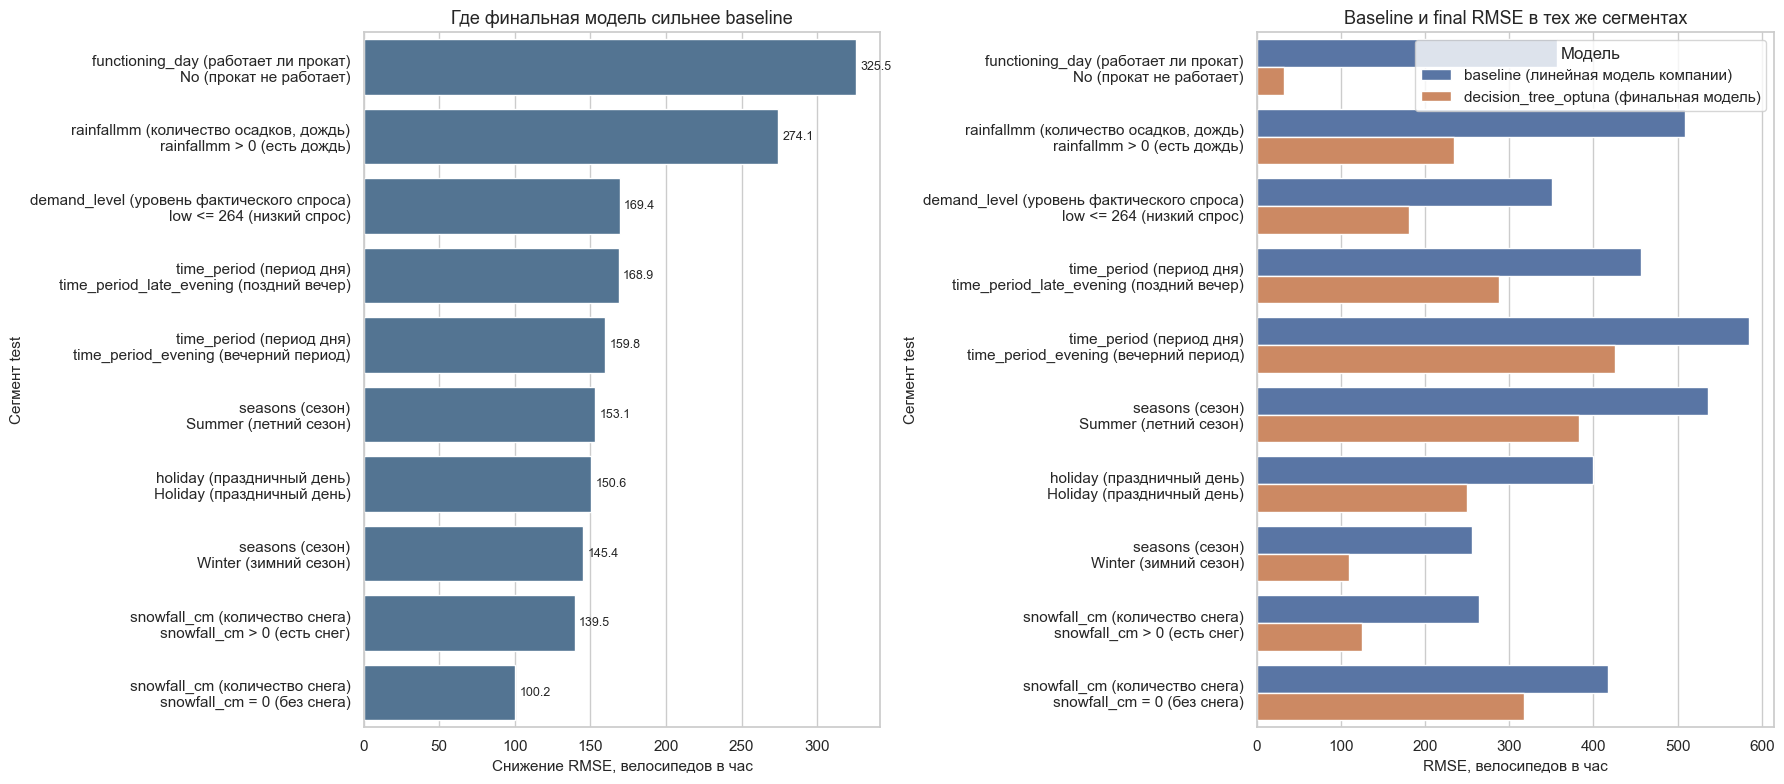

In [20]:
plot_segments = segment_results.head(10).copy()
plot_segments["segment_label"] = plot_segments["segment_group"] + "\n" + plot_segments["segment_value"].astype(str)

rmse_pair_plot = plot_segments.melt(
    id_vars=["segment_label"],
    value_vars=["baseline_RMSE", "final_RMSE"],
    var_name="model",
    value_name="RMSE",
)
rmse_pair_plot["model"] = rmse_pair_plot["model"].map(
    {
        "baseline_RMSE": "baseline (линейная модель компании)",
        "final_RMSE": f"{best_model_name} (финальная модель)",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=plot_segments, y="segment_label", x="RMSE_delta", ax=axes[0], color="#49759c")
axes[0].set_title("Где финальная модель сильнее baseline")
axes[0].set_xlabel("Снижение RMSE, велосипедов в час")
axes[0].set_ylabel("Сегмент test")
add_bar_labels(axes[0], "%.1f")

sns.barplot(data=rmse_pair_plot, y="segment_label", x="RMSE", hue="model", ax=axes[1])
axes[1].set_title("Baseline и final RMSE в тех же сегментах")
axes[1].set_xlabel("RMSE, велосипедов в час")
axes[1].set_ylabel("Сегмент test")
axes[1].legend(title="Модель")

plt.tight_layout()
plt.show()


**Интерпретация сегментного аудита:** этот блок показывает, что улучшение не прячется только в одной средней цифре. Если модель сильнее baseline в пиковом спросе, погодных режимах и рабочих часах, она полезнее для планирования смен и доступности велосипедов. Если где-то выигрыш слабый или отрицательный, такой сегмент нужно отдельно смотреть при пилоте, а не замазывать общей метрикой.


<a id="stage-8"></a>
## Этап 8. Интерпретация и артефакты

Теперь нужно понять, почему модель принимает такие решения, и сохранить ее так, чтобы результат можно было открыть вне ноутбука. Без этого хорошая метрика остается одноразовым экспериментом.


,feature_technical,feature_description_ru,importance
0,temperature,температура воздуха,0.3396
11,time_period_night,ночной период,0.1743
12,dew_point_gap,разница температуры и точки росы,0.1137
29,functioning_day_Yes,прокат работает,0.1118
8,time_period_evening,вечерний период,0.0870
9,time_period_late_evening,поздний вечер,0.0464
27,seasons_Winter,зимний сезон,0.0351
20,temp_x_solar,temp x solar,0.0229
15,has_precipitation,has precipitation,0.0143
4,dew_point_temperature,температура точки росы,0.0120


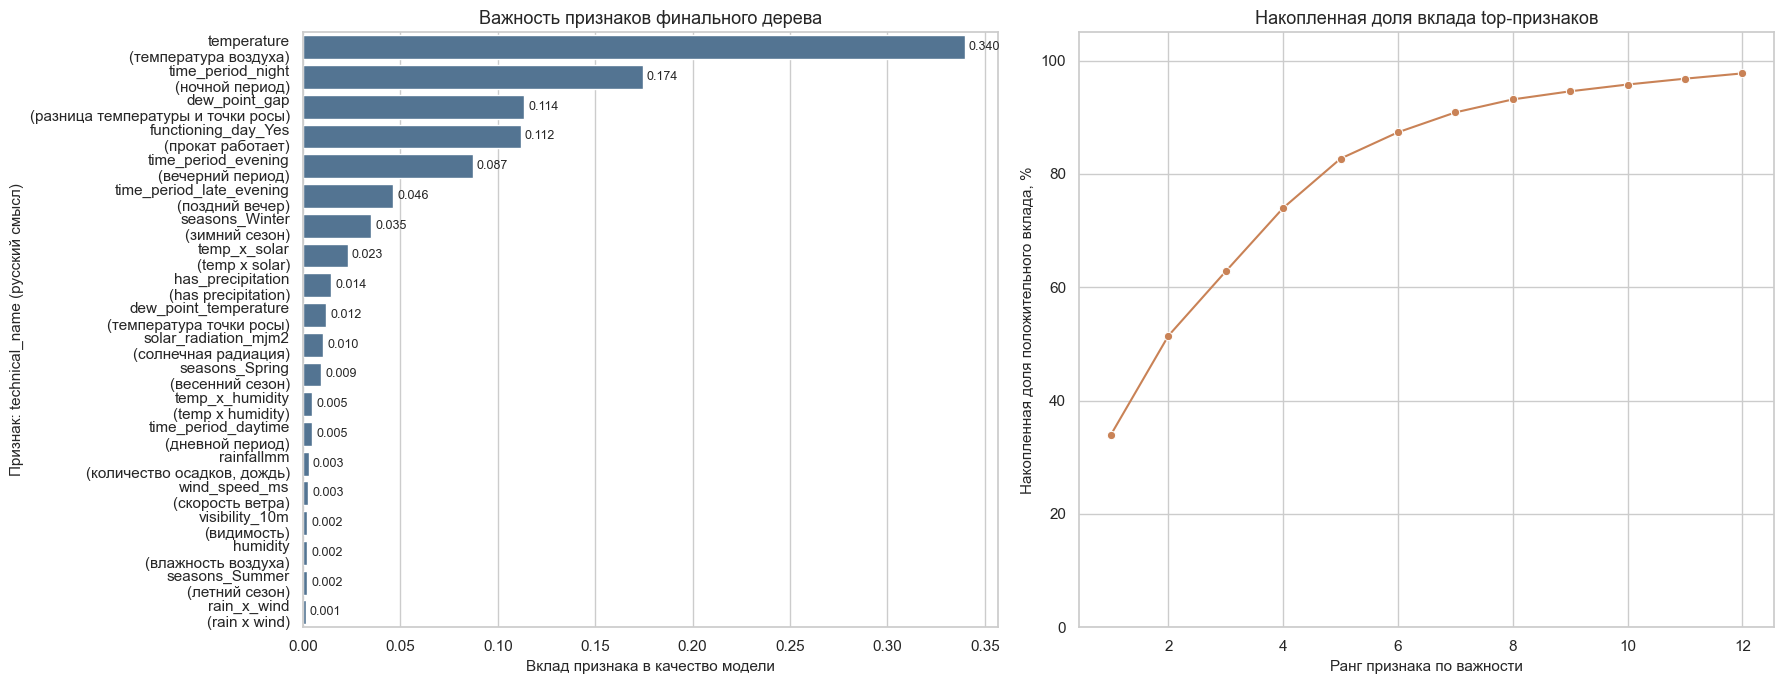

In [21]:
if best_model_name == "decision_tree_optuna":
    feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = final_pipeline.named_steps["model"].feature_importances_
    importance_table = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20)
    )
    importance_title = "Важность признаков финального дерева"
else:
    permutation = permutation_importance(
        final_pipeline,
        X_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    importance_table = (
        pd.DataFrame(
            {
                "feature": X_test.columns,
                "importance": permutation.importances_mean,
                "importance_std": permutation.importances_std,
            }
        )
        .sort_values("importance", ascending=False)
        .head(20)
    )
    importance_title = "Permutation importance финальной KNN-модели"

feature_labels = [
    feature_label_for_reader(feature)
    for feature in importance_table["feature"].astype(str).tolist()
]
importance_table[["feature_technical", "feature_description_ru", "feature_plot_label"]] = pd.DataFrame(
    feature_labels, index=importance_table.index
)
display(
    importance_table[
        ["feature_technical", "feature_description_ru", "importance"]
        + (["importance_std"] if "importance_std" in importance_table.columns else [])
    ]
)

importance_plot = importance_table.copy()
importance_plot["rank"] = np.arange(1, len(importance_plot) + 1)
importance_plot["positive_importance"] = importance_plot["importance"].clip(lower=0)
total_positive_importance = importance_plot["positive_importance"].sum()
importance_plot["cumulative_positive_share_pct"] = (
    importance_plot["positive_importance"].cumsum() / total_positive_importance * 100
    if total_positive_importance > 0
    else np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=importance_plot, y="feature_plot_label", x="importance", ax=axes[0], color="#49759c")
axes[0].set_title(importance_title)
axes[0].set_xlabel("Вклад признака в качество модели")
axes[0].set_ylabel("Признак: technical_name (русский смысл)")
add_bar_labels(axes[0], "%.3f")

sns.lineplot(
    data=importance_plot.head(12),
    x="rank",
    y="cumulative_positive_share_pct",
    marker="o",
    ax=axes[1],
    color="#c98256",
)
axes[1].set_title("Накопленная доля вклада top-признаков")
axes[1].set_xlabel("Ранг признака по важности")
axes[1].set_ylabel("Накопленная доля положительного вклада, %")
axes[1].set_ylim(0, 105)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


In [22]:
model_artifact_path = MODELS_DIR / "bike_demand_model.joblib"
metadata_path = MODELS_DIR / "bike_demand_model_metadata.json"
predictions_path = MODELS_DIR / "bike_demand_test_predictions.csv"
model_card_path = MODELS_DIR / "bike_demand_model_card.json"
manifest_path = MODELS_DIR / "bike_demand_artifact_manifest.json"
artifact_inventory_path = MODELS_DIR / "bike_demand_artifact_inventory.csv"

joblib.dump(final_pipeline, model_artifact_path)

predictions_frame = X_test.copy()
predictions_frame[TARGET] = y_test.values
predictions_frame["prediction"] = final_test_predictions
predictions_frame["residual"] = y_test.values - final_test_predictions
predictions_frame.to_csv(predictions_path, index=False)

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

required_component_names = [
    "BikeFeatureEngineer",
    "BASE_NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "TIME_FEATURES",
    "BASE_FEATURES",
    "ENGINEERED_FEATURES",
    "NUMERIC_WITH_ENGINEERED",
    "MODEL_FEATURES_AFTER_ENGINEERING",
]
component_module = importlib.import_module(COMPONENT_MODULE_NAME)
component_symbol_check = pd.DataFrame(
    [
        {"required_name": name, "present": hasattr(component_module, name)}
        for name in required_component_names
    ]
)
component_symbols_ok = bool(component_symbol_check["present"].all())
assert component_symbols_ok, "Feature engineering component module is incomplete"

component_source_sha256 = file_sha256(COMPONENT_MODULE_PATH)

baseline_test_metrics = final_results.query(
    "model == 'company_linear_baseline' and split == 'test'"
).iloc[0].to_dict()
final_test_metrics = final_results.query(
    "model == @best_model_name and split == 'test'"
).iloc[0].to_dict()

model_card = {
    "project": "bike_demand_regression",
    "business_goal": "прогнозировать почасовой спрос на велосипеды для операционного планирования BikeSouth",
    "target": TARGET,
    "primary_metric": "RMSE",
    "secondary_metrics": ["MAE", "R2", "negative_predictions"],
    "selected_model": best_model_name,
    "selected_params": final_params,
    "test_quality": final_test_metrics,
    "baseline_test_quality": baseline_test_metrics,
    "rmse_improvement_pct_vs_baseline": float(rmse_improvement_pct),
    "training_protocol": {
        "model_selection": f"{CV_SPLITS}-fold CV только на train",
        "test_usage": "одна финальная оценка после выбора модели",
        "random_state": RANDOM_STATE,
        "optuna_trials": {"knn": N_TRIALS_KNN, "decision_tree": N_TRIALS_TREE},
    },
    "input_contract": {
        "required_columns": X_train.columns.tolist(),
        "target_column": TARGET,
        "row_grain": "одна строка = один час наблюдений велопроката",
        "not_required_at_inference": [TARGET],
    },
    "feature_engineering_contract": {
        "module": COMPONENT_MODULE_NAME,
        "source_path": str(COMPONENT_MODULE_PATH.relative_to(PROJECT_ROOT)),
        "source_sha256": component_source_sha256,
        "required_names": required_component_names,
    },
    "known_limitations": [
        "test-выборка относится к той же исходной распределенной среде, что и train; это не будущий out-of-time период",
        "перед использованием в необычную погоду, праздники или новый режим работы нужна повторная проверка",
        "часы с нулевым спросом при работающем прокате и часы неработающего проката требуют отдельного мониторинга",
    ],
    "monitoring_recommendations": [
        "RMSE, MAE, R2 и число отрицательных прогнозов на свежих размеченных партиях",
        "доля часов с нулевым спросом и строк с неработающим прокатом",
        "drift распределений температуры, влажности, дождя, снега и time-period признаков",
        "ошибка прогноза по сезонам, времени суток, праздникам и functioning_day",
    ],
}

component_manifest = {
    "component_module": COMPONENT_MODULE_NAME,
    "component_source_path": str(COMPONENT_MODULE_PATH),
    "component_source_sha256": component_source_sha256,
    "required_component_names": required_component_names,
    "component_symbols_ok": component_symbols_ok,
    "pipeline_steps": [name for name, _ in final_pipeline.steps],
    "preprocessor_transformers": [
        name for name, _, _ in final_pipeline.named_steps["preprocessor"].transformers
    ],
    "model_class": type(final_pipeline.named_steps["model"]).__name__,
    "model_params": final_params,
}

metadata = {
    "project": "bike_demand_regression",
    "random_state": RANDOM_STATE,
    "cv_splits": CV_SPLITS,
    "selected_model": best_model_name,
    "selected_params": final_params,
    "baseline_test_metrics": baseline_test_metrics,
    "final_test_metrics": final_test_metrics,
    "rmse_improvement_pct_vs_baseline": rmse_improvement_pct,
    "train_shape": train.shape,
    "test_shape": test.shape,
    "input_columns": X_train.columns.tolist(),
    "engineered_features": ENGINEERED_FEATURES,
    "component_module": COMPONENT_MODULE_NAME,
    "component_source_sha256": component_source_sha256,
    "required_component_names": required_component_names,
    "versions": versions.to_dict(orient="records"),
    "artifact_paths": {
        "model": str(model_artifact_path),
        "metadata": str(metadata_path),
        "test_predictions": str(predictions_path),
        "model_card": str(model_card_path),
        "manifest": str(manifest_path),
        "artifact_inventory": str(artifact_inventory_path),
        "component_source_module": str(COMPONENT_MODULE_PATH),
        "baseline": str(baseline_path),
    },
}

with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2, default=str)
with model_card_path.open("w", encoding="utf-8") as file:
    json.dump(model_card, file, ensure_ascii=False, indent=2, default=str)
with manifest_path.open("w", encoding="utf-8") as file:
    json.dump(component_manifest, file, ensure_ascii=False, indent=2, default=str)

production_contract = pd.DataFrame(
    [
        {
            "contract_area": "input_schema",
            "requirement": "данные для инференса должны содержать те же исходные признаки, что и train",
            "implementation": f"{len(X_train.columns)} входных колонок перечислены в model_card['input_contract']",
        },
        {
            "contract_area": "feature_engineering_code",
            "requirement": "сохраненная модель должна поставляться вместе со всем кастомным feature engineering кодом",
            "implementation": f"{COMPONENT_MODULE_NAME}.py находится в проекте; sha256={component_source_sha256[:12]}...",
        },
        {
            "contract_area": "reproducibility",
            "requirement": "предсказания артефакта после reload должны совпадать с предсказаниями ноутбука",
            "implementation": "ниже выполняется joblib.load и сравнение через np.allclose",
        },
        {
            "contract_area": "monitoring",
            "requirement": "production-использование требует свежей разметки и мониторинга drift",
            "implementation": "model card содержит контроль метрик, сегментов и drift входных признаков",
        },
    ]
)

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": "model_pipeline",
            "path": str(model_artifact_path.relative_to(PROJECT_ROOT)),
            "exists": model_artifact_path.exists(),
            "purpose": "полный sklearn pipeline с feature engineering, preprocessing и моделью",
        },
        {
            "artifact": "metadata",
            "path": str(metadata_path.relative_to(PROJECT_ROOT)),
            "exists": metadata_path.exists(),
            "purpose": "метрики запуска, выбранные параметры, версии пакетов и пути артефактов",
        },
        {
            "artifact": "model_card",
            "path": str(model_card_path.relative_to(PROJECT_ROOT)),
            "exists": model_card_path.exists(),
            "purpose": "бизнес-цель, качество, входной контракт, ограничения и мониторинг",
        },
        {
            "artifact": "component_manifest",
            "path": str(manifest_path.relative_to(PROJECT_ROOT)),
            "exists": manifest_path.exists(),
            "purpose": "имена кастомных компонентов, checksum модуля и структура pipeline",
        },
        {
            "artifact": "test_predictions",
            "path": str(predictions_path.relative_to(PROJECT_ROOT)),
            "exists": predictions_path.exists(),
            "purpose": "построчные финальные test-предсказания и residuals",
        },
        {
            "artifact": "component_source_module",
            "path": str(COMPONENT_MODULE_PATH.relative_to(PROJECT_ROOT)),
            "exists": COMPONENT_MODULE_PATH.exists(),
            "purpose": "Python-код, необходимый для загрузки и работы сохраненного pipeline",
        },
        {
            "artifact": "baseline_pipeline",
            "path": str(baseline_path.relative_to(PROJECT_ROOT)),
            "exists": baseline_path.exists(),
            "purpose": "baseline компании, использованный для сравнения на test",
        },
    ]
)
artifact_inventory.to_csv(artifact_inventory_path, index=False)

reloaded_pipeline = joblib.load(model_artifact_path)
reloaded_predictions = reloaded_pipeline.predict(X_test)
reload_check = {
    "same_predictions_after_reload": bool(np.allclose(final_test_predictions, reloaded_predictions)),
    "max_abs_prediction_diff": float(np.max(np.abs(final_test_predictions - reloaded_predictions))),
}
artifact_check = pd.DataFrame(
    [
        {
            "check": "component module contains required names",
            "status": "OK" if component_symbols_ok else "FAIL",
            "detail": f"найдено {component_symbol_check['present'].sum()} из {len(required_component_names)} обязательных имен",
        },
        {
            "check": "all listed artifacts exist",
            "status": "OK" if bool(artifact_inventory["exists"].all()) else "FAIL",
            "detail": f"найдено {artifact_inventory['exists'].sum()} из {len(artifact_inventory)} артефактов",
        },
        {
            "check": "predictions match after joblib reload",
            "status": "OK" if reload_check["same_predictions_after_reload"] else "FAIL",
            "detail": f"max_abs_prediction_diff={reload_check['max_abs_prediction_diff']:.10f}",
        },
    ]
)

display(production_contract)
display(artifact_inventory)
display(component_symbol_check)
display(artifact_check)
display(pd.DataFrame([reload_check]))
assert reload_check["same_predictions_after_reload"], "Reloaded model predictions differ"
assert artifact_inventory["exists"].all(), "Some declared artifacts were not saved"


,contract_area,requirement,implementation
0,input_schema,"данные для инференса должны содержать те же исходные признаки, что и train",15 входных колонок перечислены в model_card['input_contract']
1,feature_engineering_code,сохраненная модель должна поставляться вместе со всем кастомным feature engineering кодом,bike_demand_pipeline_components.py находится в проекте; sha256=c68eb83dacac...
2,reproducibility,предсказания артефакта после reload должны совпадать с предсказаниями ноутбука,ниже выполняется joblib.load и сравнение через np.allclose
3,monitoring,production-использование требует свежей разметки и мониторинга drift,"model card содержит контроль метрик, сегментов и drift входных признаков"


,artifact,path,exists,purpose
0,model_pipeline,models\bike_demand_model.joblib,True,"полный sklearn pipeline с feature engineering, preprocessing и моделью"
1,metadata,models\bike_demand_model_metadata.json,True,"метрики запуска, выбранные параметры, версии пакетов и пути артефактов"
2,model_card,models\bike_demand_model_card.json,True,"бизнес-цель, качество, входной контракт, ограничения и мониторинг"
3,component_manifest,models\bike_demand_artifact_manifest.json,True,"имена кастомных компонентов, checksum модуля и структура pipeline"
4,test_predictions,models\bike_demand_test_predictions.csv,True,построчные финальные test-предсказания и residuals
5,component_source_module,bike_demand_pipeline_components.py,True,"Python-код, необходимый для загрузки и работы сохраненного pipeline"
6,baseline_pipeline,models\baseline_linear_regression_pipeline.joblib,True,"baseline компании, использованный для сравнения на test"


,required_name,present
0,BikeFeatureEngineer,True
1,BASE_NUMERIC_FEATURES,True
2,CATEGORICAL_FEATURES,True
3,TIME_FEATURES,True
4,BASE_FEATURES,True
5,ENGINEERED_FEATURES,True
6,NUMERIC_WITH_ENGINEERED,True
7,MODEL_FEATURES_AFTER_ENGINEERING,True


,check,status,detail
0,component module contains required names,OK,найдено 8 из 8 обязательных имен
1,all listed artifacts exist,OK,найдено 7 из 7 артефактов
2,predictions match after joblib reload,OK,max_abs_prediction_diff=0.0000000000


,same_predictions_after_reload,max_abs_prediction_diff
0,True,0.0000


**Вывод этапа 8:** сохранен не голый алгоритм, а весь pipeline: признаки, обработка пропусков, кодирование категорий и модель. Рядом лежат metadata, model card, manifest, test predictions и inventory. После `joblib.load()` прогнозы совпали, значит модель не зависит от скрытого состояния ноутбука.

Test predictions сохранены как отчетный артефакт финальной проверки, а не как данные для нового обучения.


In [23]:
baseline_test_row = final_results.query("model == 'company_linear_baseline' and split == 'test'").iloc[0]
final_test_row = final_results.query("model == @best_model_name and split == 'test'").iloc[0]
final_cv_row = cv_comparison.query("model == @best_model_name").iloc[0]

top_feature_rows = [
    feature_label_for_reader(feature)
    for feature in importance_table["feature"].head(5).astype(str).tolist()
]
top_feature_text = "; ".join(
    f"`{technical}` ({description})"
    for technical, description, _ in top_feature_rows
)
rmse_abs_improvement = baseline_test_row["RMSE"] - final_test_row["RMSE"]
mae_abs_improvement = baseline_test_row["MAE"] - final_test_row["MAE"]
r2_abs_improvement = final_test_row["R2"] - baseline_test_row["R2"]
baseline_negative_share = baseline_test_row["negative_predictions"] / len(X_test)
final_negative_share = final_test_row["negative_predictions"] / len(X_test)

final_calculated_summary = f"""
<a id="final-conclusions"></a>

# Финальные выводы

## Расчетные итоги

- Выбранная модель: `{best_model_name}`.
- CV train: `RMSE = {final_cv_row["cv_RMSE_mean"]:.2f} ± {final_cv_row["cv_RMSE_std"]:.2f}`, `MAE = {final_cv_row["cv_MAE_mean"]:.2f}`, `R2 = {final_cv_row["cv_R2_mean"]:.3f}`.
- Baseline test: `RMSE = {baseline_test_row["RMSE"]:.2f}`, `MAE = {baseline_test_row["MAE"]:.2f}`, `R2 = {baseline_test_row["R2"]:.3f}`.
- Final test: `RMSE = {final_test_row["RMSE"]:.2f}`, `MAE = {final_test_row["MAE"]:.2f}`, `R2 = {final_test_row["R2"]:.3f}`.
- Улучшение относительно baseline: `RMSE -{rmse_abs_improvement:.2f}` велосипеда в час (`{rmse_improvement_pct:.2f}%`), `MAE -{mae_abs_improvement:.2f}`, `R2 +{r2_abs_improvement:.3f}`.
- Отрицательные прогнозы baseline: `{int(baseline_test_row["negative_predictions"])}` из `{len(X_test)}` (`{baseline_negative_share:.1%}`), минимальный прогноз `{baseline_test_row["prediction_min"]:.2f}`.
- Отрицательные прогнозы final: `{int(final_test_row["negative_predictions"])}` из `{len(X_test)}` (`{final_negative_share:.1%}`), минимальный прогноз `{final_test_row["prediction_min"]:.2f}`, средний прогноз `{final_test_row["prediction_mean"]:.2f}`.
- Сегментный аудит: final лучше baseline в `{segment_positive_count}` из `{segment_total_count}` test-срезов; самый сильный выигрыш - `{best_segment["segment_group"]}` / `{best_segment["segment_value"]}` (`RMSE -{best_segment["RMSE_delta"]:.2f}` велосипеда в час).
- Ключевые признаки: {top_feature_text}.
- Параметры финальной модели: `{final_params}`.
- Дополнительный пункт закрыт через `BikeFeatureEngineer` внутри `Pipeline`; transformer сохранен в импортируемом модуле и проверен после `joblib.load()`.
"""

display(Markdown(final_calculated_summary))



<a id="final-conclusions"></a>

# Финальные выводы

## Расчетные итоги

- Выбранная модель: `decision_tree_optuna`.
- CV train: `RMSE = 315.88 ± 8.61`, `MAE = 210.86`, `R2 = 0.761`.
- Baseline test: `RMSE = 411.45`, `MAE = 312.53`, `R2 = 0.586`.
- Final test: `RMSE = 310.77`, `MAE = 207.43`, `R2 = 0.764`.
- Улучшение относительно baseline: `RMSE -100.69` велосипеда в час (`24.47%`), `MAE -105.10`, `R2 +0.178`.
- Отрицательные прогнозы baseline: `147` из `1752` (`8.4%`), минимальный прогноз `-715.29`.
- Отрицательные прогнозы final: `0` из `1752` (`0.0%`), минимальный прогноз `0.00`, средний прогноз `708.11`.
- Сегментный аудит: final лучше baseline в `20` из `20` test-срезов; самый сильный выигрыш - `functioning_day (работает ли прокат)` / `No (прокат не работает)` (`RMSE -325.49` велосипеда в час).
- Ключевые признаки: `temperature` (температура воздуха); `time_period_night` (ночной период); `dew_point_gap` (разница температуры и точки росы); `functioning_day_Yes` (прокат работает); `time_period_evening` (вечерний период).
- Параметры финальной модели: `{'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07, 'random_state': 42}`.
- Дополнительный пункт закрыт через `BikeFeatureEngineer` внутри `Pipeline`; transformer сохранен в импортируемом модуле и проверен после `joblib.load()`.


## Бизнес-интерпретация

Для BikeSouth это не просто "модель с метриками", а более аккуратный способ заранее оценивать нагрузку по часам. Текущая линейная baseline-модель ошибается сильнее и иногда уходит в отрицательный спрос. Финальная модель этого не делает: прогноз остается в физически возможном диапазоне, поэтому его не нужно вручную обрезать перед отчетом или пилотом.

Главный практический смысл - планирование общей нагрузки. Когда модель заранее видит высокий спрос, можно раньше подготовить парк, смены и поддержку. Когда спрос низкий, компания не держит лишний запас "на всякий случай". Ошибка все еще есть, но она стала меньше в понятной единице - велосипедах в час, а не только в абстрактной статистике.

Отдельно проверено, где именно модель выигрывает у baseline. Это важнее одной средней цифры: если улучшение заметно в сложных сегментах вроде высокого спроса, осадков или отдельных периодов дня, модель помогает там, где ошибка дороже. Слабые сегменты из аудита не нужно игнорировать - их стоит держать в мониторинге во время пилота.

Дополнительный пункт закрыт инженерно: новые признаки создаются не ручным кодом перед обучением, а внутри `BikeFeatureEngineer` в составе `Pipeline`. Это значит, что при повторном запуске, сохранении и загрузке модели используются те же правила подготовки данных. Проверка `joblib.load()` подтверждает, что модель не держится на скрытом состоянии ноутбука.

Ограничение честное: это прогноз общего спроса, а не распределение велосипедов по конкретным станциям. В данных нет запасов на станциях, городских событий, цен, ремонтов и отдельной проверки на будущем периоде. Поэтому рекомендация такая: брать модель в пилот для прогноза общей почасовой нагрузки, но перед автоматическим использованием прогнать ее на более свежем месяце и отдельно посмотреть дождь, снег, пиковые часы и нулевой спрос. Все артефакты для такого пилота сохранены: pipeline, metadata, model card, manifest, predictions и inventory.
